In [1]:
# If not installed already (uncomment as needed):
# !pip install torch torch-geometric pandas tqdm

import os, json, torch, pandas as pd
from pathlib import Path
import importlib

import data_utils
importlib.reload(data_utils)

from data_utils import load_graphs, attach_labels_and_noisy, build_loaders
from train_loop import train, evaluate

In [2]:
# EDIT THESE:
GRAPHS_PT = "../processed/graphs_train.pt"      # <-- Step 1 output (a list[Data])
LABELS_CSV = "labels_train.csv"    # <-- We'll generate a template first if it doesn't exist
MODEL_OUT  = "qem_graph_transformer.pt"


In [3]:
graphs = load_graphs(GRAPHS_PT)
print(f"Loaded {len(graphs)} graphs")
# quick sanity on shapes
g0 = graphs[0]
print("x:", tuple(g0.x.shape),
      "edge_index:", tuple(g0.edge_index.shape),
      "lightcone_masks:", tuple(g0.lightcone_masks.shape))
M = g0.lightcone_masks.shape[1]
print("Measured qubits (M):", M)


Loaded 500 graphs
x: (2071, 20) edge_index: (2, 2565) lightcone_masks: (2071, 5)
Measured qubits (M): 5


In [4]:
# This will create a template with circuit_path + zero arrays for noisy_z/target_y (len = M).
# If LABELS_CSV already exists, this cell won’t overwrite it unless you set FORCE=True.
FORCE = False

if (not Path(LABELS_CSV).exists()) or FORCE:
    rows = []
    for g in graphs:
        path = g.circuit_path if isinstance(g.circuit_path, str) else g.circuit_path[0]
        # Placeholder arrays (fill these with your real noisy/ideal values):
        zeros = [0.0] * g.lightcone_masks.shape[1]
        rows.append({
            "circuit_path": path,
            "noisy_z_json": json.dumps(zeros),
            "target_y_json": json.dumps(zeros)
        })
    df = pd.DataFrame(rows)
    df.to_csv(LABELS_CSV, index=False)
    print(f"Template written to {LABELS_CSV} with {len(df)} rows and M={M}.")
    display(df.head(3))
else:
    print(f"{LABELS_CSV} already exists — not overwriting. Set FORCE=True to regenerate.")


labels_train.csv already exists — not overwriting. Set FORCE=True to regenerate.


In [14]:
import data_utils
importlib.reload(data_utils)

from data_utils import load_graphs, attach_labels_and_noisy, build_loaders_by_train_val_paths

# Make sure you've filled LABELS_CSV before running this cell.
# graphs, M = attach_labels_and_noisy(graphs, LABELS_CSV)  # validates M consistency
# print(f"Graphs ready with labels. M={M}")


graphs = load_graphs(GRAPHS_PT)
graphs, M = attach_labels_and_noisy(graphs, "labels_train.csv")



# train_loader, val_loader = build_loaders(graphs, batch_size=4, val_frac=0.8, seed=42)

train_loader, val_loader = build_loaders_by_train_val_paths(
    graphs, train_data_paths, test_data_paths, batch_size=4, shuffle_train=False
)



len(train_loader), len(val_loader)


[build] train=100 | val=400 | M=5


(25, 100)

In [15]:
iterator = iter(train_loader)
batch = next(iterator)

In [16]:
batch

DataBatch(x=[16471, 20], edge_index=[2, 20427], num_nodes=16471, lightcone_masks=[16471, 5], measured_qubits=[20], num_measured=[4], num_qubits=[4], depth_layers=[4], circuit_path=[4], split=[4], noisy_z=[20], y=[20], batch=[16471], ptr=[5])

In [18]:
# You can tune these a bit; keep it small because of low data.
model_cfg = dict(d_model=128, layers=3, heads=4, dropout=0.1, use_noisy=True)

net, hist = train(model_cfg, (train_loader, val_loader),
                  epochs=100, lr=1e-3, wd=1e-4, patience=30, device='cuda',
                  best_ckpt_path="best_qem_graph_transformer.pt")

# net is already restored to the best-validated state

# torch.save(net.state_dict(), MODEL_OUT)
# print("Saved:", MODEL_OUT)


Epoch 001 | train 0.0721 | val 0.0468 | MAE 0.2279
Epoch 002 | train 0.0617 | val 0.0443 | MAE 0.2222
Epoch 003 | train 0.0566 | val 0.0479 | MAE 0.2381
Epoch 004 | train 0.0553 | val 0.0478 | MAE 0.2394
Epoch 005 | train 0.0533 | val 0.0456 | MAE 0.2333
Epoch 006 | train 0.0514 | val 0.0445 | MAE 0.2316
Epoch 007 | train 0.0479 | val 0.0371 | MAE 0.2073
Epoch 008 | train 0.0434 | val 0.0301 | MAE 0.1840
Epoch 009 | train 0.0388 | val 0.0205 | MAE 0.1345
Epoch 010 | train 0.0348 | val 0.0168 | MAE 0.1274
Epoch 011 | train 0.0291 | val 0.0119 | MAE 0.1013
Epoch 012 | train 0.0200 | val 0.0084 | MAE 0.0986
Epoch 013 | train 0.0139 | val 0.0068 | MAE 0.1011
Epoch 014 | train 0.0095 | val 0.0034 | MAE 0.0679
Epoch 015 | train 0.0067 | val 0.0023 | MAE 0.0557
Epoch 016 | train 0.0053 | val 0.0018 | MAE 0.0505
Epoch 017 | train 0.0046 | val 0.0025 | MAE 0.0640
Epoch 018 | train 0.0033 | val 0.0017 | MAE 0.0523
Epoch 019 | train 0.0030 | val 0.0014 | MAE 0.0476
Epoch 020 | train 0.0026 | val 

In [19]:
total_params = sum(param.numel() for param in net.parameters())
print(f"Total number of parameters: {total_params}")


Total number of parameters: 251393


In [20]:
import torch.nn as nn
crit = nn.SmoothL1Loss()
device = "cuda" if torch.cuda.is_available() else "cpu"
metrics = evaluate(net, val_loader, crit, device=device)
metrics


{'loss': 0.0002380774418634246, 'mae': 0.014388159956783057}

Per-qubit MAE (model): [0.015255467966198921, 0.013917200267314911, 0.014707855880260468, 0.014212062582373619, 0.013848209753632545]


/tmp/ipykernel_3954220/3332857812.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


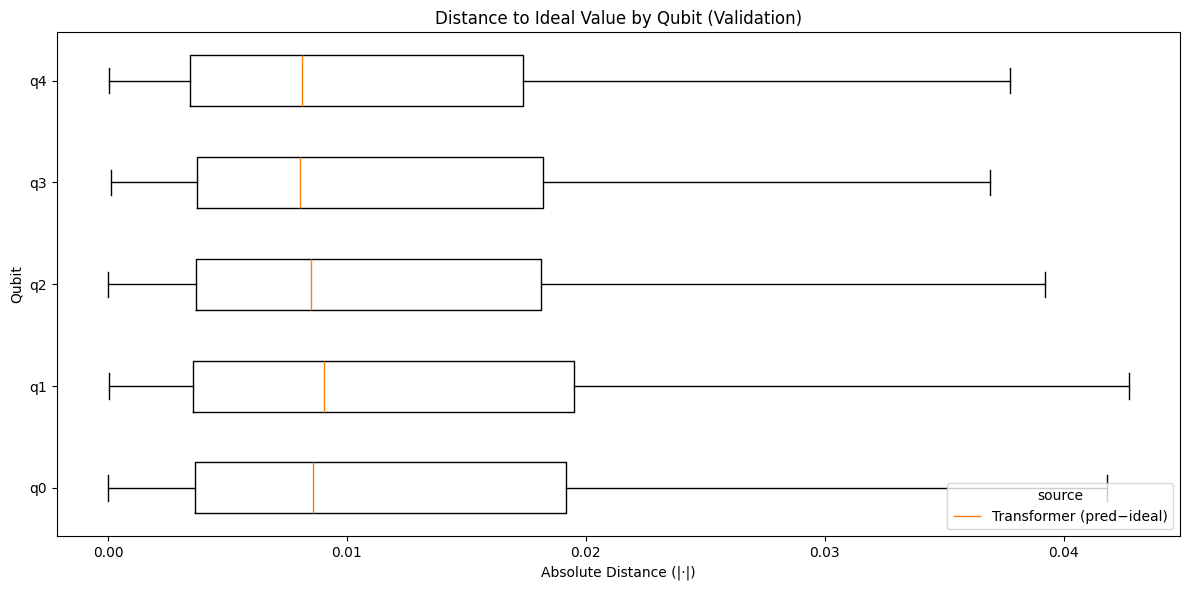

In [21]:
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
M = next(iter(val_loader)).lightcone_masks.shape[1]

@torch.no_grad()
def collect_pred_target_noisy(loader, model, M, device):
    model.eval()
    P, Y, N = [], [], []
    for batch in loader:
        batch = batch.to(device)
        y_hat = model(batch)            # [B*M]
        P.append(y_hat.detach().cpu())
        Y.append(batch.y.detach().cpu())
        N.append(batch.noisy_z.detach().cpu())
    P = torch.cat(P, 0).view(-1, M)     # [S, M]
    Y = torch.cat(Y, 0).view(-1, M)     # [S, M]
    N = torch.cat(N, 0).view(-1, M)     # [S, M]
    return P, Y, N

P, Y, N = collect_pred_target_noisy(val_loader, net, M, device)

# ---- Per-qubit MAE (model) ----
per_qubit_mae = (P - Y).abs().mean(dim=0).tolist()
print("Per-qubit MAE (model):", per_qubit_mae)

# ---- Distances to plot ----
dist_model = (P - Y).abs()   # what you want on the plot
dist_noisy = (N - Y).abs()   # optional baseline

def plot_distance_boxplot(dist_by_source, qubit_labels=None, title="Distance to Ideal by Qubit"):
    first = next(iter(dist_by_source.values()))
    S, M = first.shape
    if qubit_labels is None:
        qubit_labels = [f"q{i}" for i in range(M)]

    fig = plt.figure(figsize=(12, 6))
    ax = plt.gca()
    base_positions = torch.arange(M).float()
    K = len(dist_by_source)
    offsets = torch.linspace(-0.25, 0.25, steps=K) if K > 1 else torch.tensor([0.0])

    handles = []
    for j, (name, D) in enumerate(dist_by_source.items()):
        data = [D[:, q].numpy() for q in range(M)]
        positions = (base_positions + offsets[j]).tolist()
        bp = ax.boxplot(
            data,
            positions=positions,
            vert=False,
            widths=0.5,
            patch_artist=False,
            manage_ticks=False,
            showfliers=False,
            whis=1.5,
            labels=None,
        )
        handles.append(bp["medians"][0])

    ax.set_yticks(base_positions.tolist())
    ax.set_yticklabels(qubit_labels)
    ax.set_xlabel("Absolute Distance (|·|)")
    ax.set_ylabel("Qubit")
    ax.set_title(title)
    ax.legend(handles, list(dist_by_source.keys()), loc="lower right", title="source")
    fig.tight_layout()
    plt.show()

# ---- Plot (model vs optional baseline) ----
plot_distance_boxplot(
    {
        "Transformer (pred−ideal)": dist_model,
        # "Noisy (noisy−ideal)": dist_noisy,   # uncomment to compare baseline
    },
    qubit_labels=[f"q{i}" for i in range(M)],
    title="Distance to Ideal Value by Qubit (Validation)",
)


In [20]:
import json
import numpy as np

def boxplot_stats_from_tensor(D):
    """Return per-qubit boxplot statistics from [S, M] tensor."""
    stats = []
    for q in range(D.shape[1]):
        arr = D[:, q].numpy()
        q1 = np.percentile(arr, 25)
        q3 = np.percentile(arr, 75)
        median = np.median(arr)
        whisker_low = arr[arr >= q1 - 1.5 * (q3 - q1)].min()
        whisker_high = arr[arr <= q3 + 1.5 * (q3 - q1)].max()
        stats.append({
            "qbit": int(q),
            "q1": float(q1),
            "q3": float(q3),
            "median": float(median),
            "whisker_low": float(whisker_low),
            "whisker_high": float(whisker_high),
        })
    return stats

# Example: save for model distances
stats_model = boxplot_stats_from_tensor(dist_model)
stats_noisy = boxplot_stats_from_tensor(dist_noisy)

# Save to JSON
save_path = "boxplot_stats.json"
with open(save_path, "w") as f:
    json.dump({
        "Transformer (pred−ideal)": stats_model,
        "Noisy (noisy−ideal)": stats_noisy,
    }, f, indent=2)
print(f"Saved stats to {save_path}")


Saved stats to boxplot_stats.json


# Comparison

In [6]:
import json, os, pickle
import numpy as np
from tqdm.notebook import tqdm
import pandas as pd

import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import qiskit.circuit.random
import torch, random
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn as nn

import numpy as np
import json, os, pickle
from tqdm import tqdm
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from qiskit import QuantumCircuit

import sys
sys.path.append('../../../tutorials/')
from mlp import encode_data, encode_data_v2_ecr

In [7]:
def check_f(f, f_ext, step_indices):
    return f.endswith(f_ext) and any([f"step_%02d"%step_index in f for step_index in step_indices])

def load_circuits(data_dir, step_indices, f_ext='.pk'):
    Js = []
    circuits = []
    data_paths = []
    data_files = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if check_f(f, f_ext, step_indices)])
    for data_file in tqdm(data_files, leave=True):
        for entry in pickle.load(open(data_file, 'rb')):
            Js.append(entry['J'])
            circuits.append(entry['circuit'])
        data_paths.append(data_file[3:])
    return data_paths, circuits, Js

In [8]:
data_paths, circuits, Js = load_circuits('../../../tutorials/data/ising_zne_hardware/100q_brisbane/', list(range(1, 11)))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:43<00:00, 11.54it/s]


In [9]:
data_paths[0]

'../../tutorials/data/ising_zne_hardware/100q_brisbane/step_01_J00.pk'

In [10]:
for step_index in [1]:
    with open('../../../tutorials/zne_mitigated/twirl_100q_brisbane/step%02d.json'%step_index, 'r') as file:
        loaded = json.load(file)
    noise_factor_1 = np.array(loaded['noise_factor_1'])
    noise_factor_3 = np.array(loaded['noise_factor_3'])

for step_index in tqdm([2, 3, 4, 5, 6, 7, 8, 9, 10]):
    with open('../../../tutorials/zne_mitigated/twirl_100q_brisbane/step%02d.json'%step_index, 'r') as file:
        loaded = json.load(file)
    noise_factor_1 = np.concatenate([noise_factor_1, loaded['noise_factor_1']])
    noise_factor_3 = np.concatenate([noise_factor_3, loaded['noise_factor_3']])

noise_factor_1_tw_avg = noise_factor_1.reshape(noise_factor_1.shape[0], 5, 5).mean(axis=-1)
noise_factor_3_tw_avg = noise_factor_3.reshape(noise_factor_3.shape[0], 5, 5).mean(axis=-1)

slope = (noise_factor_3_tw_avg - noise_factor_1_tw_avg) / 2
zne_mitigated_vals = (noise_factor_1_tw_avg - slope).tolist()
noisy_vals = noise_factor_1_tw_avg.tolist()
len(zne_mitigated_vals)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 44.38it/s]


500

In [11]:
print(len(circuits), len(zne_mitigated_vals), len(noisy_vals), len(data_paths))

500 500 500 500


In [12]:
num_circ_per_step = 50
k = train_test_split = 10
train_circuits = []
train_zne_vals = []
train_data_paths = []
train_noisy_vals = []
test_circuits = []
test_data_paths = []
test_zne_vals = []
test_noisy_vals = []
test_Js = []
for start_each_step in list(range(len(circuits))[::num_circ_per_step]):
    train_circuits += circuits[start_each_step:start_each_step+k]
    train_data_paths += data_paths[start_each_step:start_each_step+k]
    train_zne_vals += zne_mitigated_vals[start_each_step:start_each_step+k]
    train_noisy_vals += noisy_vals[start_each_step:start_each_step+k]
    test_circuits += circuits[start_each_step+k:start_each_step+num_circ_per_step]
    test_data_paths += data_paths[start_each_step+k:start_each_step+num_circ_per_step]
    test_zne_vals += zne_mitigated_vals[start_each_step+k:start_each_step+num_circ_per_step]
    test_noisy_vals += noisy_vals[start_each_step+k:start_each_step+num_circ_per_step]
    test_Js += Js[start_each_step+k:start_each_step+num_circ_per_step]

In [13]:
print(len(train_circuits), len(train_zne_vals), len(train_noisy_vals), len(train_data_paths))
print(len(test_circuits), len(test_zne_vals), len(test_noisy_vals), len(test_data_paths))

100 100 100 100
400 400 400 400


In [22]:
few_normal_X_train, few_normal_y_train = encode_data_v2_ecr(train_circuits, train_zne_vals, train_noisy_vals, obs_size=5)
few_normal_X_test, few_normal_y_test = encode_data_v2_ecr(test_circuits, test_zne_vals, test_noisy_vals, obs_size=5)

In [23]:
BATCH_SIZE = 32
few_normal_train_dataset = TensorDataset(torch.Tensor(few_normal_X_train), torch.Tensor(few_normal_y_train))
few_normal_train_loader = DataLoader(few_normal_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
few_normal_test_dataset = TensorDataset(torch.Tensor(few_normal_X_test), torch.Tensor(few_normal_y_test))
few_normal_test_loader = DataLoader(few_normal_test_dataset, batch_size=BATCH_SIZE*1000, shuffle=False)

In [24]:
few_normal_X_train = pd.DataFrame(few_normal_X_train)
few_normal_y_train = pd.DataFrame(few_normal_y_train)
few_normal_X_test = pd.DataFrame(few_normal_X_test)
few_normal_y_test = pd.DataFrame(few_normal_y_test)

In [25]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

few_normal_rfr_tree_list = []
for q in range(5):
    rfr = RandomForestRegressor(n_estimators=100, verbose=0, n_jobs=-1)
    rfr.fit(few_normal_X_train, few_normal_y_train.iloc[:, q])
    few_normal_rfr_tree_list.append(rfr)
    print(f"Done with the {q} model")

Done with the 0 model
Done with the 1 model
Done with the 2 model
Done with the 3 model
Done with the 4 model


RMSE_noisy_0: 0.06622940680866209
RMSE_mitigated_0: 0.03107189196155334
RMSE_noisy_1: 0.06571337924238625
RMSE_mitigated_1: 0.033672658227984986
RMSE_noisy_2: 0.0654646813056526
RMSE_mitigated_2: 0.035233558869793506
RMSE_noisy_3: 0.06489176308232669
RMSE_mitigated_3: 0.036440168445860316
RMSE_noisy_4: 0.06681302970392002
RMSE_mitigated_4: 0.03812533449396915
RMSE_noisy: 0.0655765734696172
RMSE_mitigated: 0.034163576837046086


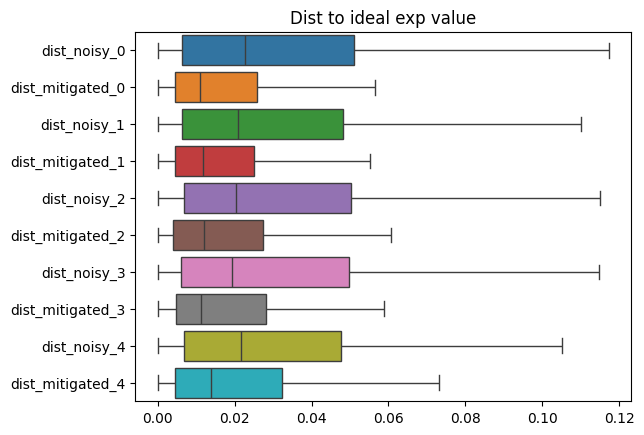

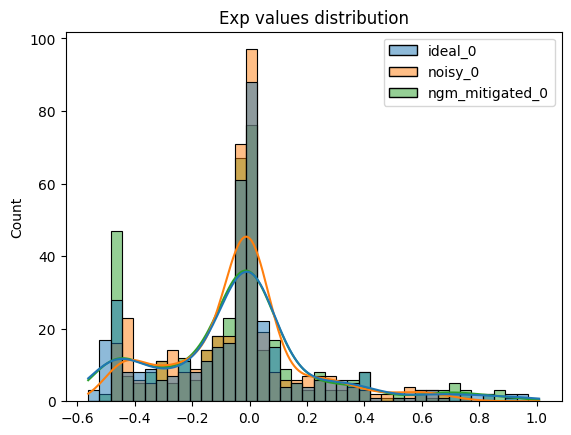

In [26]:
distances = []

num_spins = 5

for batch_X, batch_y in few_normal_test_loader:
    out = []
    for q, model in enumerate(few_normal_rfr_tree_list):
        out.append(model.predict(batch_X[:, :]))
    out = np.array(out).transpose()

    for ideal, noisy, ngm_mitigated in zip(
        batch_y.tolist(),
        batch_X[:, -5:].tolist(),
        out.tolist()
    ):
        for q in range(5):
            ideal_q = ideal[q]
            noisy_q = noisy[q]
            ngm_mitigated_q = ngm_mitigated[q]
            distances.append({
                f"ideal_{q}": ideal_q,
                f"noisy_{q}": noisy_q,
                f"ngm_mitigated_{q}": ngm_mitigated_q,
                f"dist_noisy_{q}": np.abs(ideal_q - noisy_q),
                f"dist_mitigated_{q}": np.abs(ideal_q - ngm_mitigated_q),
                f"dist_sq_noisy_{q}": np.square(ideal_q - noisy_q),
                f"dist_sq_mitigated_{q}": np.square(ideal_q - ngm_mitigated_q),
            })

plt.style.use({'figure.facecolor':'white'})

df = pd.DataFrame(distances)

for q in range(5):
    print(f'RMSE_noisy_{q}:', np.sqrt(df[f"dist_sq_noisy_{q}"].mean()))
    print(f'RMSE_mitigated_{q}:', np.sqrt(df[f"dist_sq_mitigated_{q}"].mean()))

print(f'RMSE_noisy:', np.sqrt(np.mean([df[f"dist_sq_noisy_{q}"].mean() for q in range(4)])))
print(f'RMSE_mitigated:', np.sqrt(np.mean([df[f"dist_sq_mitigated_{q}"].mean() for q in range(4)])))

sns.boxplot(data=df[["dist_noisy_0", "dist_mitigated_0", "dist_noisy_1", "dist_mitigated_1", "dist_noisy_2", "dist_mitigated_2", "dist_noisy_3", "dist_mitigated_3", "dist_noisy_4", "dist_mitigated_4"]], orient="h", showfliers = False)
plt.title("Dist to ideal exp value")
plt.show()

sns.histplot([df['ideal_0'], df['noisy_0'], df["ngm_mitigated_0"]], kde=True, bins=40)
plt.title("Exp values distribution")
plt.show()

In [27]:
def evaluate_loader(test_loader, model_list, label: str, n_qbits=5):
    results = []

    for batch_X, batch_y in test_loader:
        predictions = []
        for q, model in enumerate(model_list):
            predictions.append(model.predict(batch_X[:, :]))
        predictions = np.array(predictions).transpose()

        for ideal, noisy_or_normal, mitigated in zip(
            batch_y.tolist(),
            batch_X[:, -5:].tolist(),
            predictions.tolist()
        ):
            for q in range(n_qbits):
                ideal_q = ideal[q]
                noisy_q = noisy_or_normal[q]
                mitigated_q = mitigated[q]

                results.append({
                    "source": label,
                    f"ideal_{q}": ideal_q,
                    f"input_{q}": noisy_q,
                    f"mitigated_{q}": mitigated_q,
                    f"dist_{q}": np.abs(ideal_q - noisy_q),
                    f"dist_mitigated_{q}": np.abs(ideal_q - mitigated_q),
                    f"dist_sq_{q}": np.square(ideal_q - noisy_q),
                    f"dist_sq_mitigated_{q}": np.square(ideal_q - mitigated_q),
                })
    return results

import torch
import numpy as np

def evaluate_pyg_loader(pyg_loader, net, label: str, n_qbits=5, device=None):
    """
    Produces a list[dict] with the same keys as your RF evaluate_loader().
    - 'input' = noisy_z
    - 'mitigated' = model prediction
    - 'ideal' = y (target)
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    net.eval()
    results = []
    with torch.no_grad():
        for batch in pyg_loader:
            batch = batch.to(device)
            # Shapes: y_hat, y, noisy are [B*M]; we'll reshape to [B, M]
            y_hat = net(batch).detach().cpu()
            y     = batch.y.detach().cpu()
            noisy = batch.noisy_z.detach().cpu()

            # infer M from masks
            M = batch.lightcone_masks.shape[1]
            B = y_hat.numel() // M

            y_hat = y_hat.view(B, M).numpy()
            y     = y.view(B, M).numpy()
            noisy = noisy.view(B, M).numpy()

            for ideal_row, noisy_row, mitig_row in zip(y, noisy, y_hat):
                row = {"source": label}
                for q in range(n_qbits):
                    ideal_q     = float(ideal_row[q])
                    noisy_q     = float(noisy_row[q])
                    mitigated_q = float(mitig_row[q])
                    row.update({
                        f"ideal_{q}": ideal_q,
                        f"input_{q}": noisy_q,
                        f"mitigated_{q}": mitigated_q,
                        f"dist_{q}": abs(ideal_q - noisy_q),
                        f"dist_mitigated_{q}": abs(ideal_q - mitigated_q),
                        f"dist_sq_{q}": (ideal_q - noisy_q) ** 2,
                        f"dist_sq_mitigated_{q}": (ideal_q - mitigated_q) ** 2,
                    })
                results.append(row)
    return results


In [28]:
few_normal_results = evaluate_loader(few_normal_test_loader, few_normal_rfr_tree_list, label="RF")
gnn_val_results = evaluate_pyg_loader(val_loader, net, label="QTransMLP", n_qbits=5)

all_results = few_normal_results + gnn_val_results
df = pd.DataFrame(all_results)

In [29]:
for q in range(5):
    for label in ["RF+CLIP+LargeData", "RF+LargeData", "RF", "RF+SimulatedAndrewData", "RF+RealAndrewData", "QTransMLP"]:
        subset = df[df["source"] == label]
        rmse = np.sqrt(subset[f"dist_sq_{q}"].mean())
        rmse_mitigated = np.sqrt(subset[f"dist_sq_mitigated_{q}"].mean())
        print(f"[{label}] RMSE_input_{q}: {rmse:.4f}, RMSE_mitigated_{q}: {rmse_mitigated:.4f}")

print("------ Overall RMSEs ------")
for label in ["RF+CLIP+LargeData", "RF+LargeData", "RF", "RF+SimulatedAndrewData", "RF+RealAndrewData", "QTransMLP"]:
    subset = df[df["source"] == label]
    rmse = np.sqrt(np.mean([subset[f"dist_sq_{q}"].mean() for q in range(5)]))
    rmse_mitigated = np.sqrt(np.mean([subset[f"dist_sq_mitigated_{q}"].mean() for q in range(5)]))
    print(f"[{label}] RMSE_input: {rmse:.4f}, RMSE_mitigated: {rmse_mitigated:.4f}")



[RF+CLIP+LargeData] RMSE_input_0: nan, RMSE_mitigated_0: nan
[RF+LargeData] RMSE_input_0: nan, RMSE_mitigated_0: nan
[RF] RMSE_input_0: 0.0662, RMSE_mitigated_0: 0.0311
[RF+SimulatedAndrewData] RMSE_input_0: nan, RMSE_mitigated_0: nan
[RF+RealAndrewData] RMSE_input_0: nan, RMSE_mitigated_0: nan
[QTransMLP] RMSE_input_0: 0.0662, RMSE_mitigated_0: 0.0235
[RF+CLIP+LargeData] RMSE_input_1: nan, RMSE_mitigated_1: nan
[RF+LargeData] RMSE_input_1: nan, RMSE_mitigated_1: nan
[RF] RMSE_input_1: 0.0657, RMSE_mitigated_1: 0.0337
[RF+SimulatedAndrewData] RMSE_input_1: nan, RMSE_mitigated_1: nan
[RF+RealAndrewData] RMSE_input_1: nan, RMSE_mitigated_1: nan
[QTransMLP] RMSE_input_1: 0.0657, RMSE_mitigated_1: 0.0202
[RF+CLIP+LargeData] RMSE_input_2: nan, RMSE_mitigated_2: nan
[RF+LargeData] RMSE_input_2: nan, RMSE_mitigated_2: nan
[RF] RMSE_input_2: 0.0655, RMSE_mitigated_2: 0.0352
[RF+SimulatedAndrewData] RMSE_input_2: nan, RMSE_mitigated_2: nan
[RF+RealAndrewData] RMSE_input_2: nan, RMSE_mitigated_2

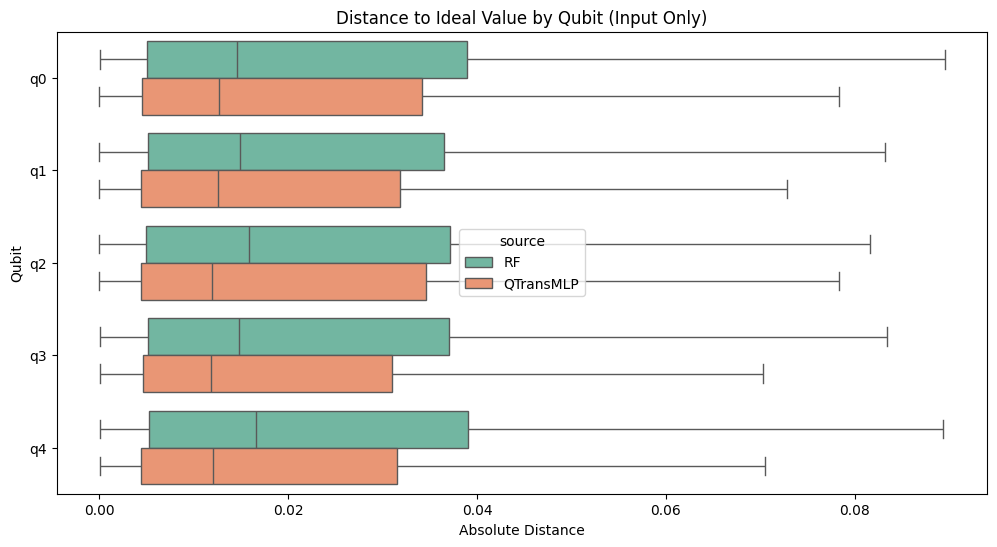

In [30]:
melted = pd.DataFrame()

for q in range(5):
    for metric in ["dist", "dist_mitigated"]:
        temp = df[[f"{metric}_{q}", "source"]].copy()
        temp = temp.rename(columns={f"{metric}_{q}": "value"})
        temp["qubit"] = f"q{q}"
        temp["type"] = "input" if "dist_" == metric else "mitigated"
        melted = pd.concat([melted, temp], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted, x="value", y="qubit", hue="source", palette="Set2", showfliers=False)
plt.title("Distance to Ideal Value by Qubit (Input Only)")
plt.xlabel("Absolute Distance")
plt.ylabel("Qubit")
# plt.savefig("RF-vs-GTrains-best.png")
plt.show()


# Mimic Results

400it [01:31,  4.36it/s]


Merged rows: 400 | RF rows: 400 | TX rows: 400


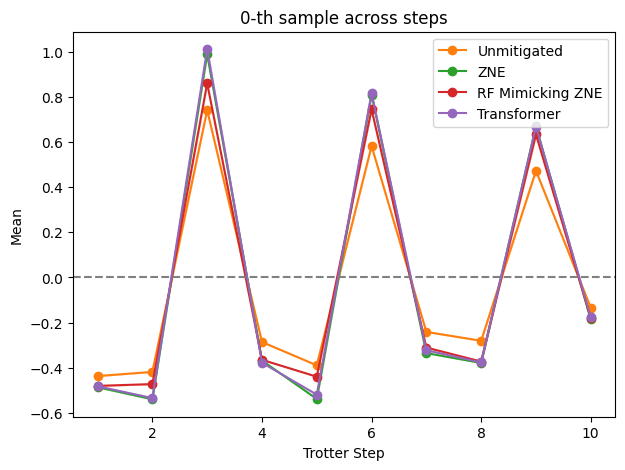

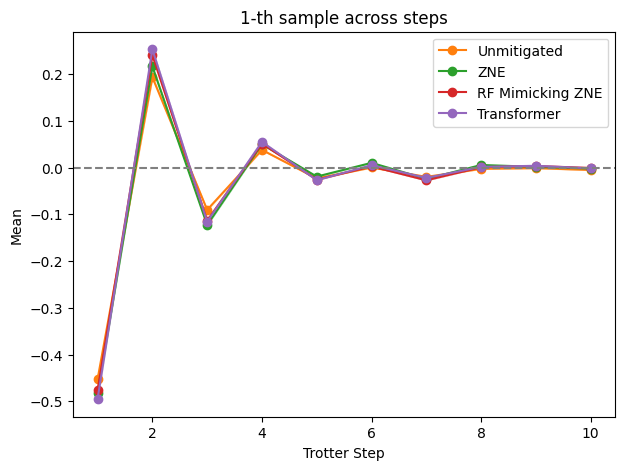

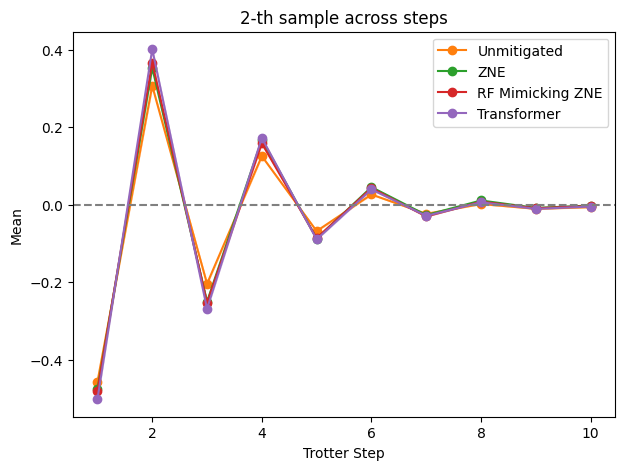

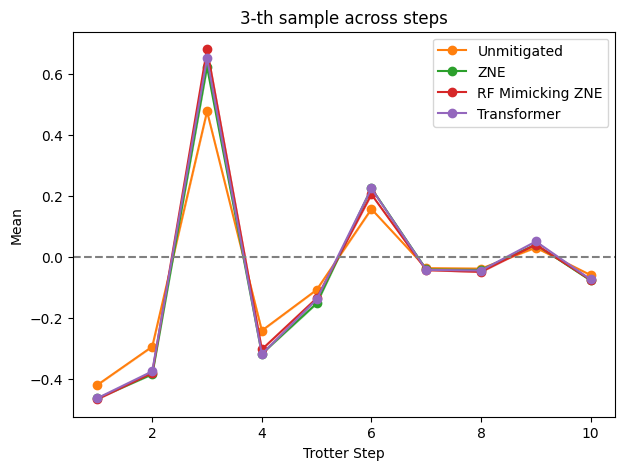

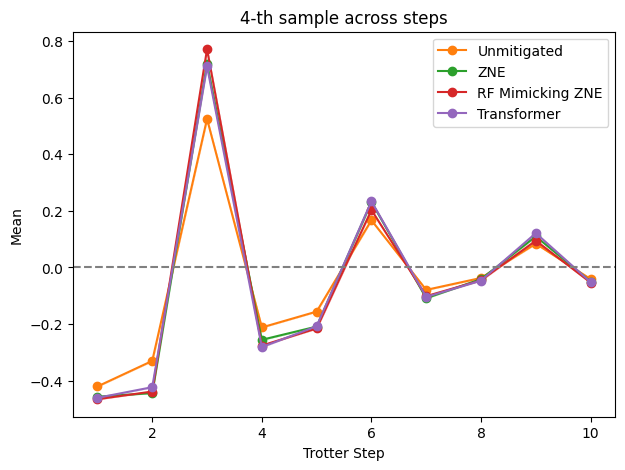

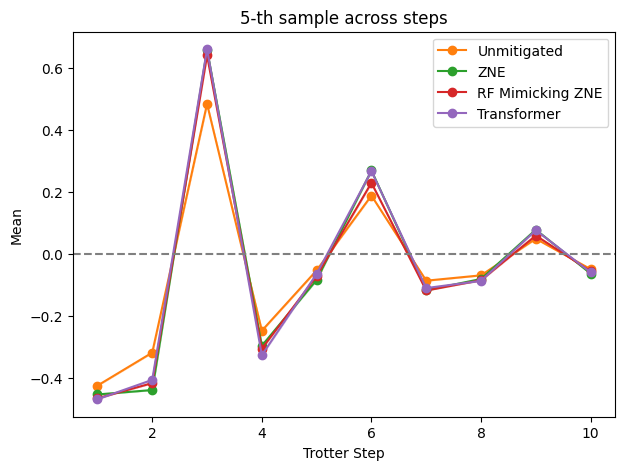

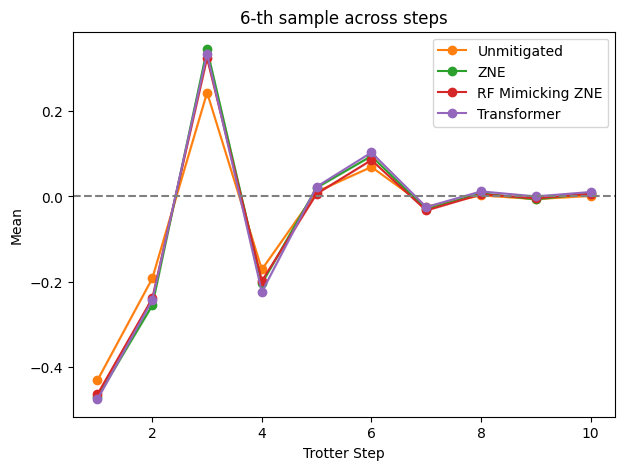

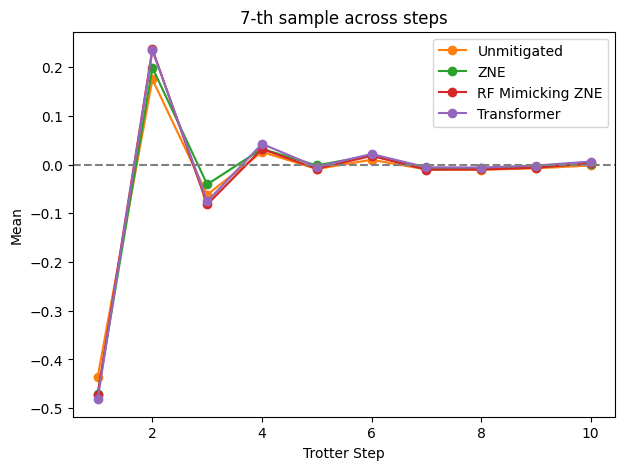

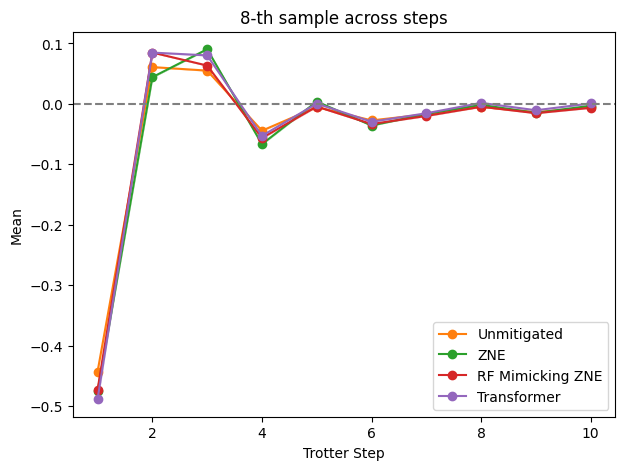

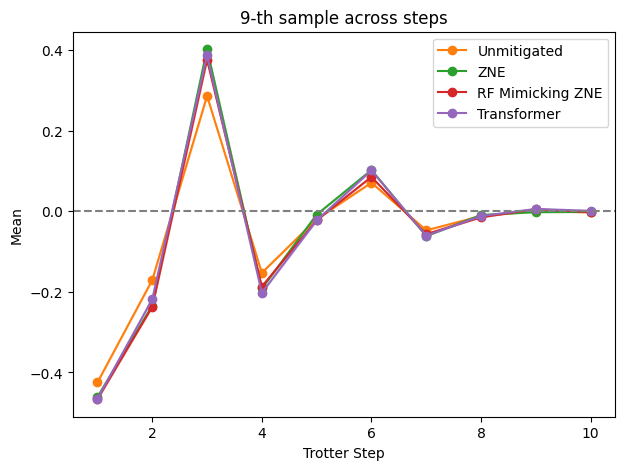

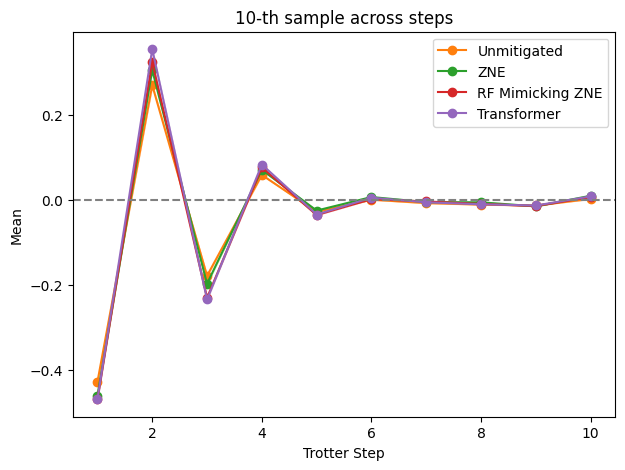

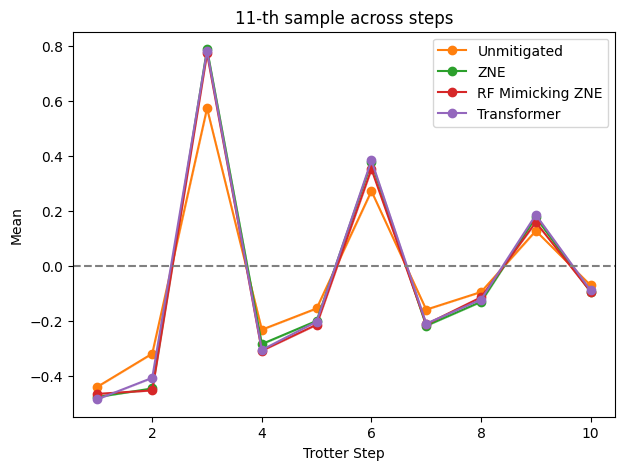

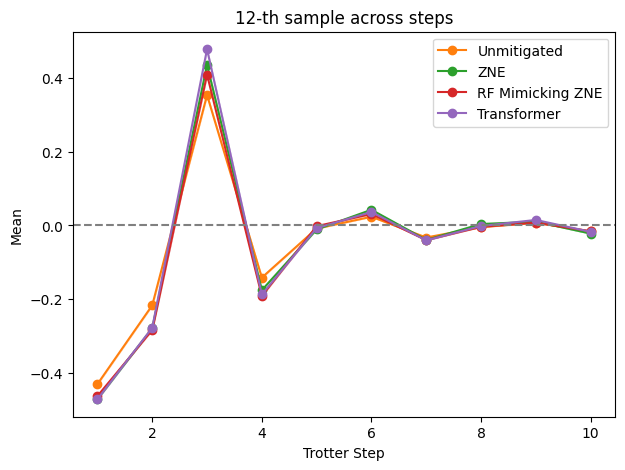

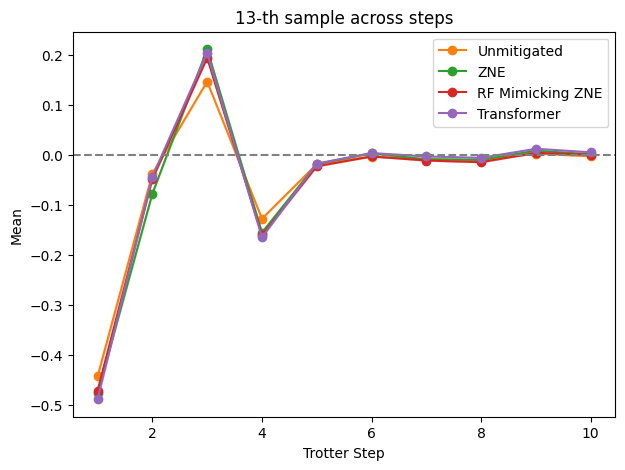

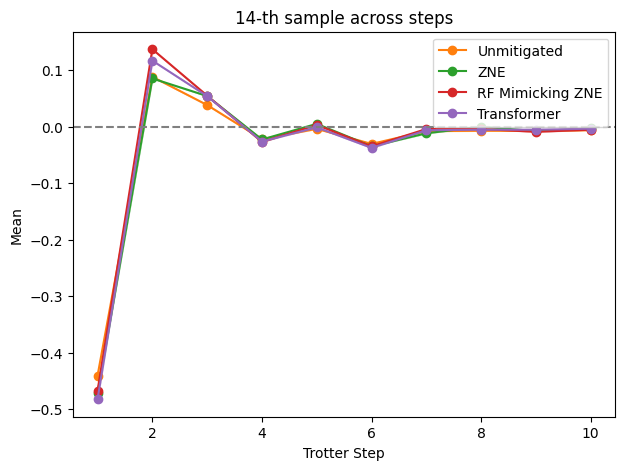

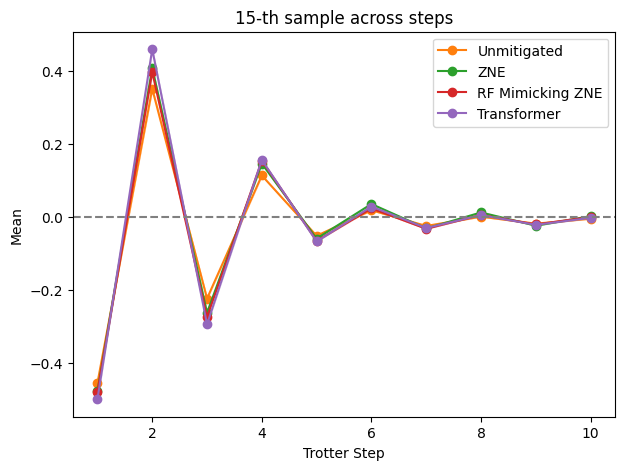

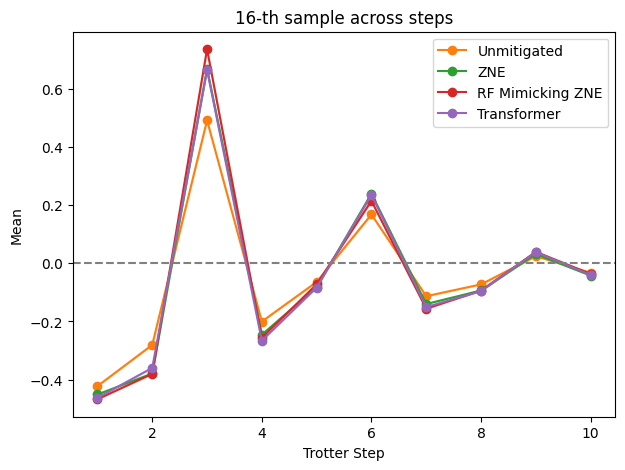

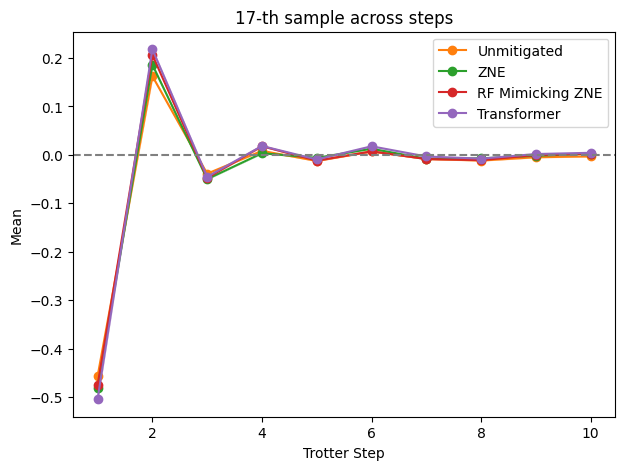

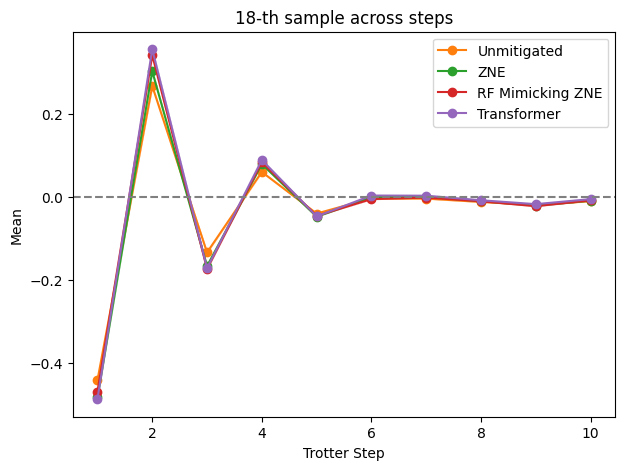

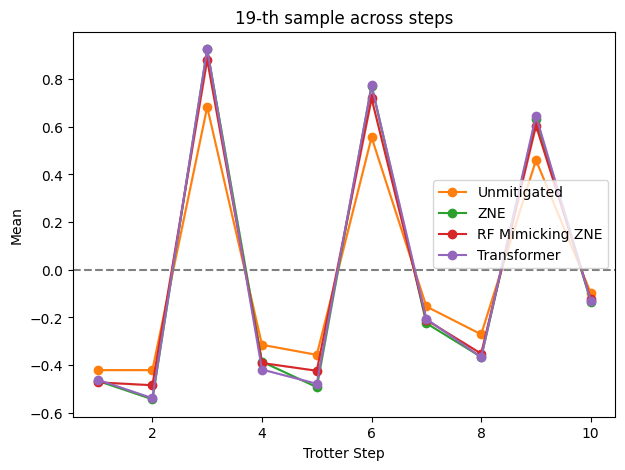

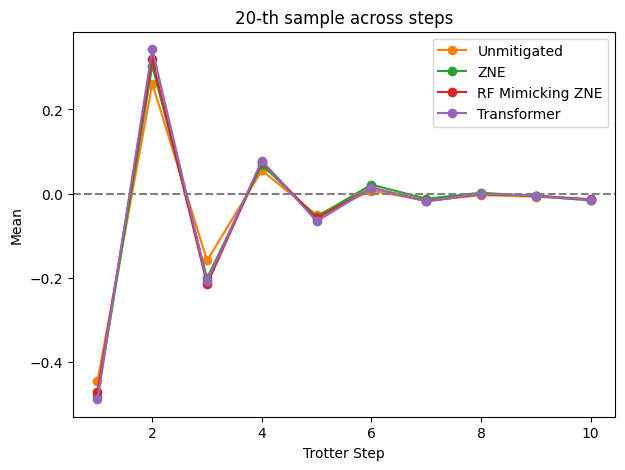

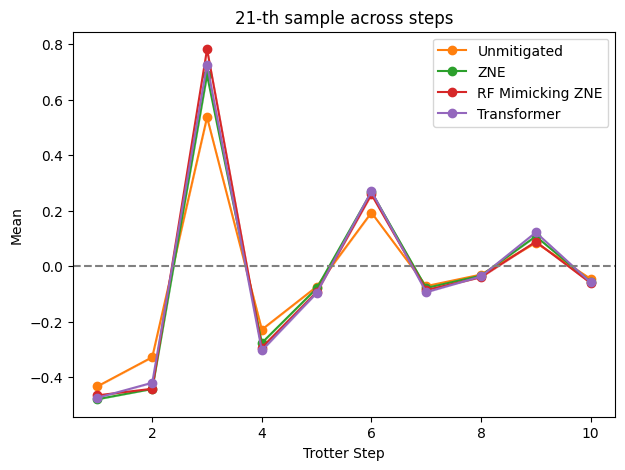

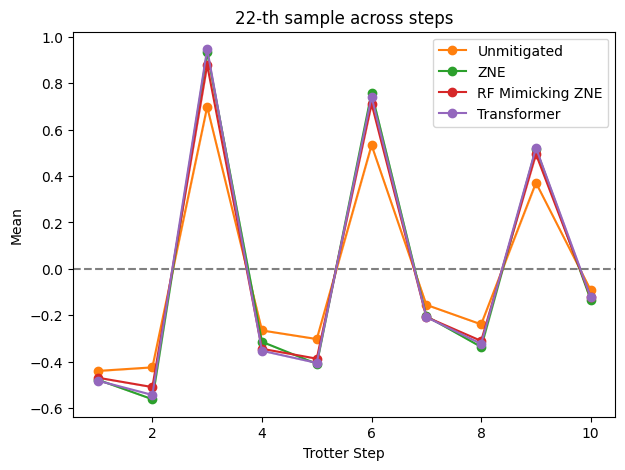

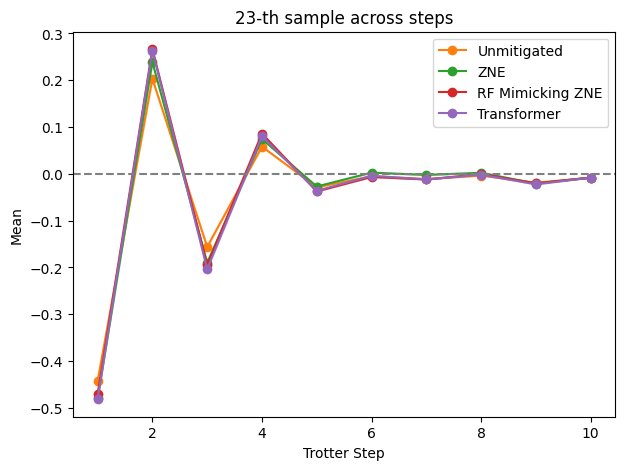

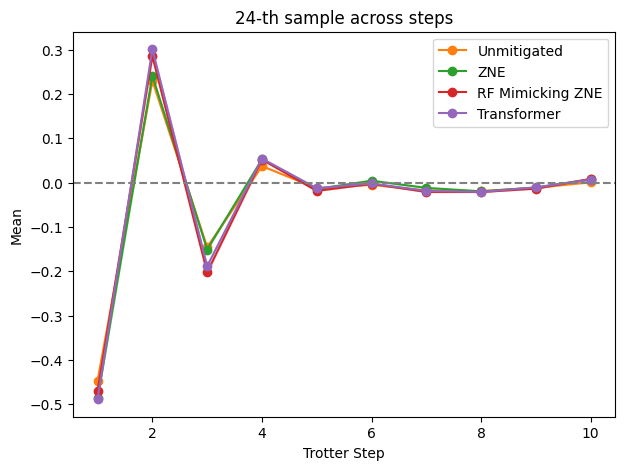

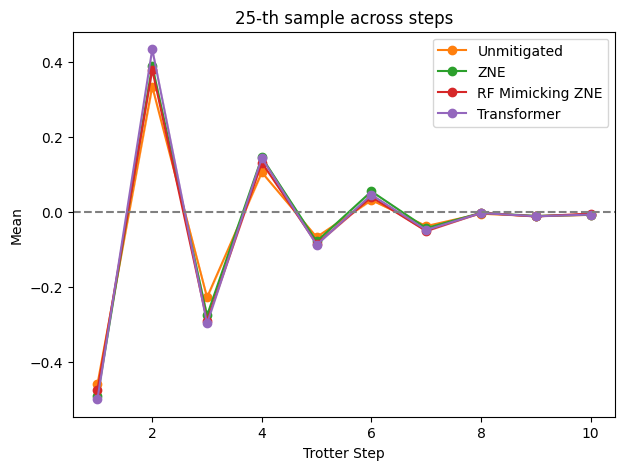

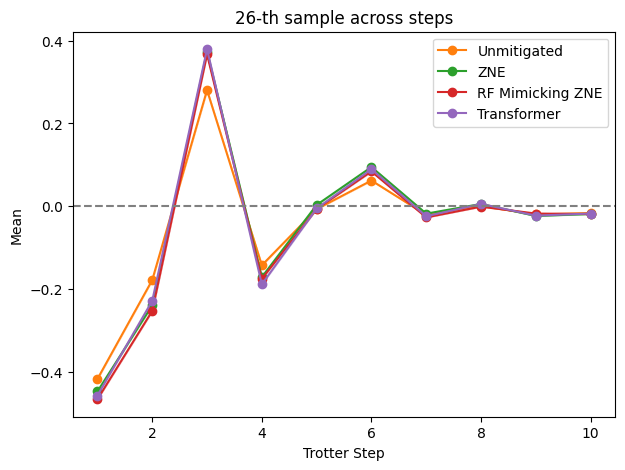

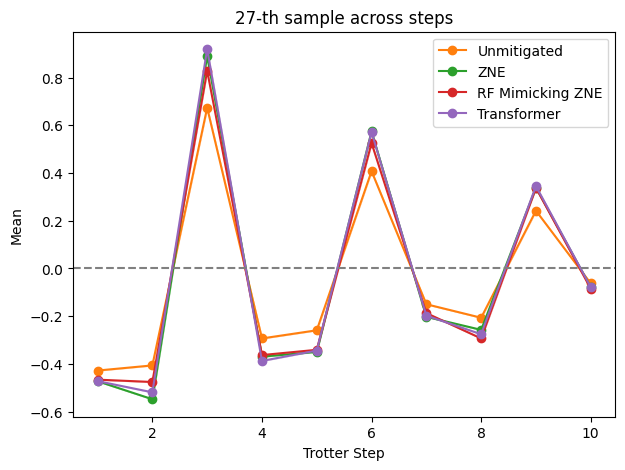

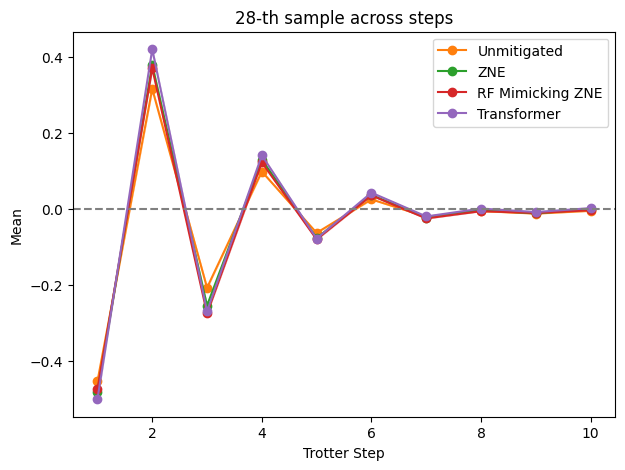

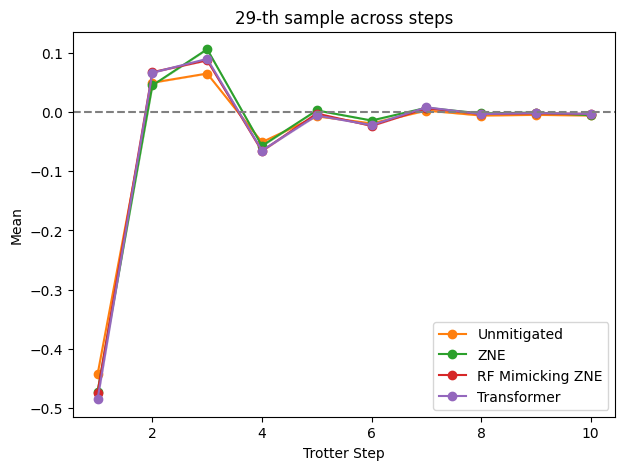

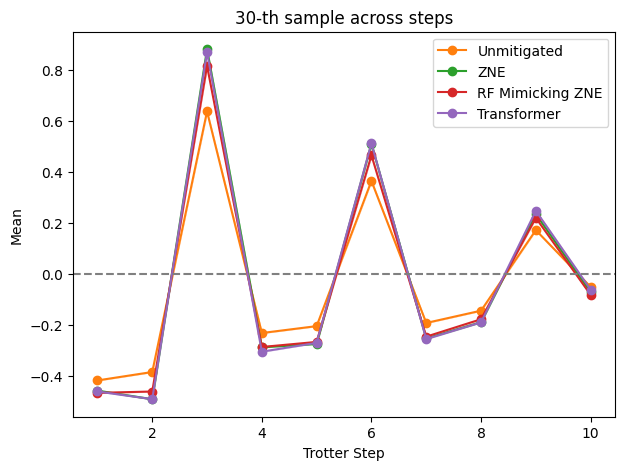

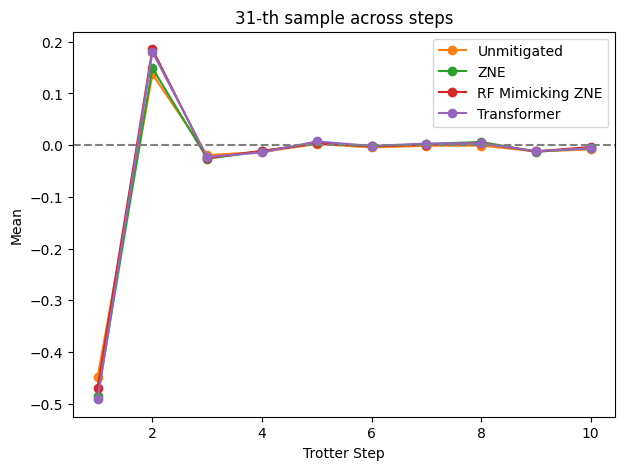

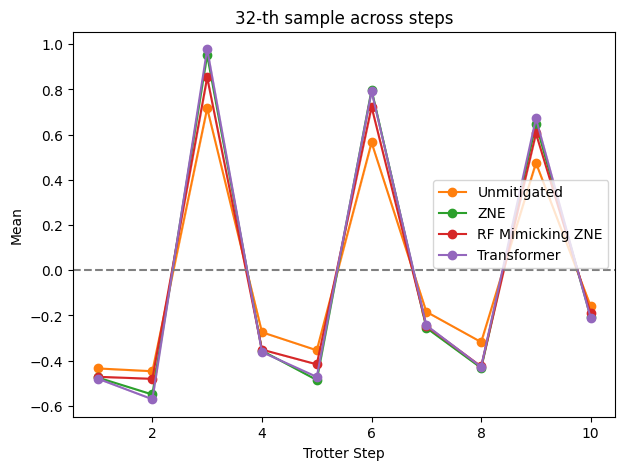

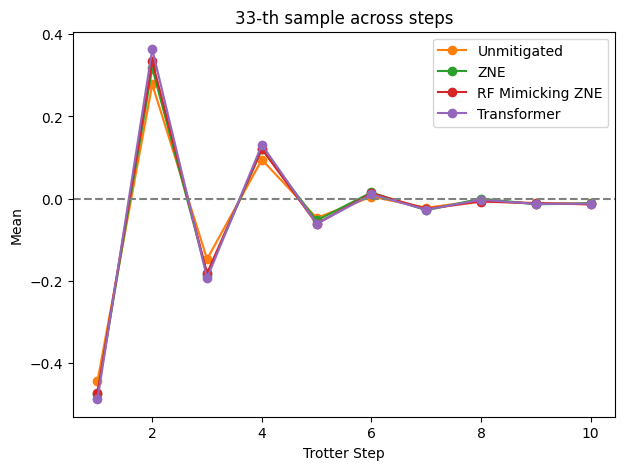

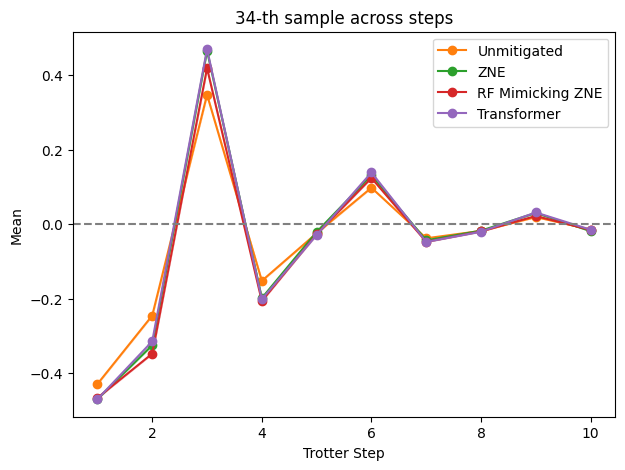

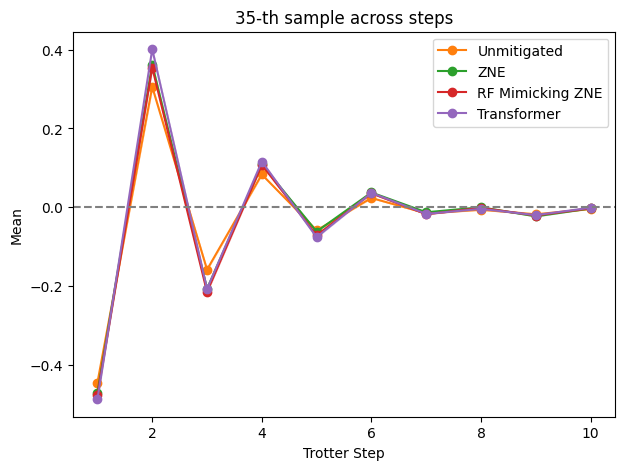

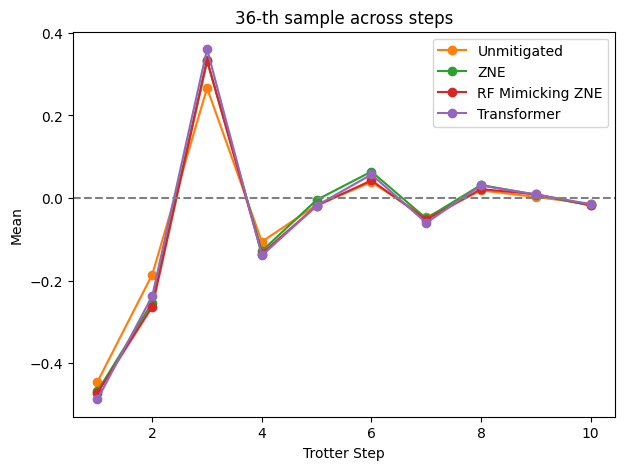

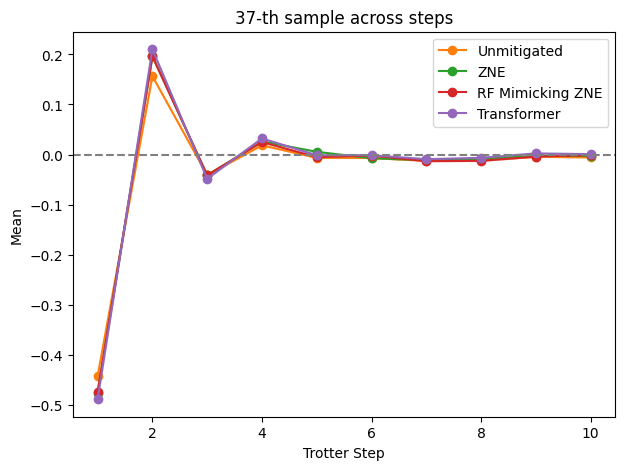

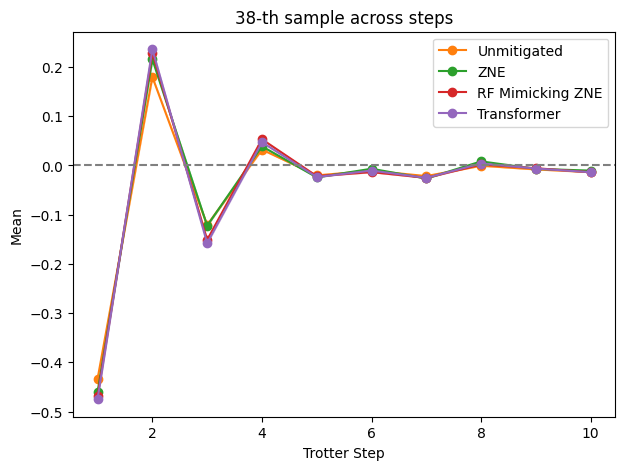

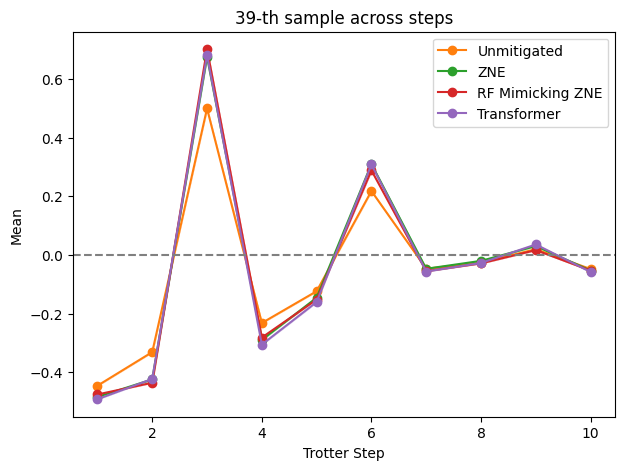

In [31]:
import numpy as np
import pandas as pd
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
M = 5
NUM_STEPS = 10
n_per_step = (num_circ_per_step - train_test_split)

# ---------- Helpers ----------
def _to_str_path(p):
    # Robust path normalizer for PyG batch fields
    if isinstance(p, str):
        return p
    if isinstance(p, (bytes, bytearray)):
        return p.decode()
    if isinstance(p, (list, tuple)):
        return _to_str_path(p[0]) if len(p) else ""
    return str(p)

# ---------- 1) RF/ZNE rows (keyed by circuit_path) ----------
steps_arr = np.repeat(np.arange(1, NUM_STEPS + 1), n_per_step)

models = [(few_normal_rfr_tree_list, 'rfr_list')]  # your RF list-of-trees

rf_rows = []
for circ_trans, noisy_exp_val, zne_mitigated, step, J, circ_path in tqdm(zip(
    test_circuits, test_noisy_vals, test_zne_vals, steps_arr, test_Js, test_data_paths)   # <-- include test_paths
):
    row = {
        "circuit_path": _to_str_path(circ_path),
        "step": int(step),
        "J": float(J),
        "noisy": noisy_exp_val,          # length-M vector
        "zne_mitigated": zne_mitigated,  # length-M vector (your “ideal”)
    }

    X, _ = encode_data_v2_ecr([circ_trans], [zne_mitigated], [noisy_exp_val], obs_size=M)

    for model, name in models:
        if name == 'mlp':
            row[name] = model(X).tolist()[0]
        elif name == 'gnn':
            # keep if you actually use this branch
            row[name] = model(entry.noisy_0, entry.observable, entry.circuit_depth,
                              entry.x, entry.edge_index, entry.batch).tolist()[0]
        elif name in ['ols_full', 'rfr_full']:
            row[name] = model.predict(X).tolist()[0]
        elif name in ['ols', 'rfr']:
            row[name] = model.predict(X[:, -M:]).tolist()[0]
        elif name == 'rfr_list':
            preds = [m.predict(X) for m in model]             # list of [1, M]
            row[name] = np.array(preds).transpose()[0]        # -> [M]
        elif name == 'zne':
            row[name] = zne_mitigated
        else:
            raise NotImplementedError

    rf_rows.append(row)
    # break

df_rf = pd.DataFrame(rf_rows)

# ---------- 2) Transformer rows (same split/loader), keyed by circuit_path ----------
tx_rows = []
net.eval()
with torch.no_grad():
    for batch in val_loader:  # test and val are the same set in your note
        batch = batch.to(device)
        y_hat = net(batch).detach().cpu().view(-1, M).tolist()

        # Extract per-graph circuit paths from the batch
        paths = [ _to_str_path(p)[:-4] for p in batch.circuit_path ]  # Data.circuit_path saved in conversion

        assert len(paths) == len(y_hat), "batch paths and preds length mismatch"
        for pth, pred in zip(paths, y_hat):
            tx_rows.append({
                "circuit_path": pth,
                "Transformer": pred,   # [M]
            })

df_tx = pd.DataFrame(tx_rows)

# ---------- 3) Merge by circuit_path ----------
df = pd.merge(df_rf, df_tx, on="circuit_path", how="inner")

# (Optional) quick sanity: per-step counts match after merge
counts_rf = df_rf.groupby("step").size()
counts_tx = df.groupby("step").size()
for s in sorted(counts_rf.index):
    if s in counts_tx and counts_rf[s] != counts_tx[s]:
        print(f"Warning: step {s} counts differ after merge: RF={counts_rf[s]} vs merged={counts_tx[s]}")

print("Merged rows:", len(df), "| RF rows:", len(df_rf), "| TX rows:", len(df_tx))

# ---------- 4) Plot summary (same as before; now perfectly aligned) ----------
import matplotlib.pyplot as plt

VECTOR_COLS = ["noisy", "zne_mitigated", "rfr_list", "Transformer"]

def _mean_vec(v): return float(np.mean(np.asarray(v, dtype=float)))
def _ste_series(s):
    means = s.apply(_mean_vec).values
    return float(np.std(means, ddof=0) / max(1, np.sqrt(len(means))))

def summarize_by_step(df_slice):
    gb = df_slice.groupby("step", sort=True)
    out = pd.DataFrame(index=gb.size().index)
    for col in VECTOR_COLS:
        if col in df_slice.columns:
            out[f"mean_{col}"] = gb[col].apply(lambda s: float(np.mean([_mean_vec(v) for v in s])))
            out[f"ste_{col}"]  = gb[col].apply(_ste_series)
    return out

n_samples = min(40, len(df))
for k in range(n_samples):
    # kth sample across steps -> pick rows where this is the kth element within each step block
    # since we merged by path, a stable alternative is to use sample index per step:
    df_k = df.groupby("step", sort=True).nth(k).dropna(subset=["noisy"])  # one row per step if exists
    if df_k.empty:
        continue
    summ = summarize_by_step(df_k.reset_index())
    steps_sorted = summ.index.to_list()

    plt.style.use({'figure.facecolor':'white'})
    plt.figure(figsize=(7,5))
    series_specs = []
    if "mean_noisy" in summ:          series_specs.append(("Unmitigated",          "mean_noisy",          "ste_noisy"))
    if "mean_zne_mitigated" in summ:  series_specs.append(("ZNE",                  "mean_zne_mitigated",  "ste_zne_mitigated"))
    if "mean_rfr_list" in summ:       series_specs.append(("RF Mimicking ZNE",     "mean_rfr_list",       "ste_rfr_list"))
    if "mean_Transformer" in summ:    series_specs.append(("Transformer",          "mean_Transformer",    "ste_Transformer"))

    for i, (label, mean_col, ste_col) in enumerate(series_specs):
        y = summ[mean_col].values
        se = summ[ste_col].values
        plt.plot(steps_sorted, y, label=label, marker='o', color=f"C{i+1}")
        plt.fill_between(steps_sorted, y - se, y + se, alpha=0.2, color=f"C{i+1}")

    plt.title(f'{k}-th sample across steps')
    plt.xlabel('Trotter Step'); plt.ylabel('Mean')
    xmin, xmax = plt.gca().get_xlim()
    plt.xlim([xmin, xmax]); plt.axhline(0, color='gray', linestyle='dashed')
    plt.legend(); plt.grid(False); plt.show()


In [32]:
def summarize_by_step(df_slice: pd.DataFrame, n_per_step: int):
    """
    Group df_slice by step and compute mean and standard error
    for all vector-valued columns.
    """
    gb = df_slice.groupby("step")
    out = gb[["step"]].first().copy()

    # Loop over all columns in this slice (besides 'step')
    for col in df_slice.columns:
        if col == "step":
            continue
        # Some cols are arrays (like rfr_list, transformer), so wrap with np.mean
        out[f"mean_{col}"] = gb[col].apply(lambda x: np.mean(np.vstack(x), axis=0) if isinstance(x.iloc[0], (list, np.ndarray)) else x.mean())
        out[f"ste_{col}"] = gb[col].apply(lambda x: np.std(np.vstack(x), axis=0)/np.sqrt(n_per_step) if isinstance(x.iloc[0], (list, np.ndarray)) else x.std()/np.sqrt(n_per_step))

    return out


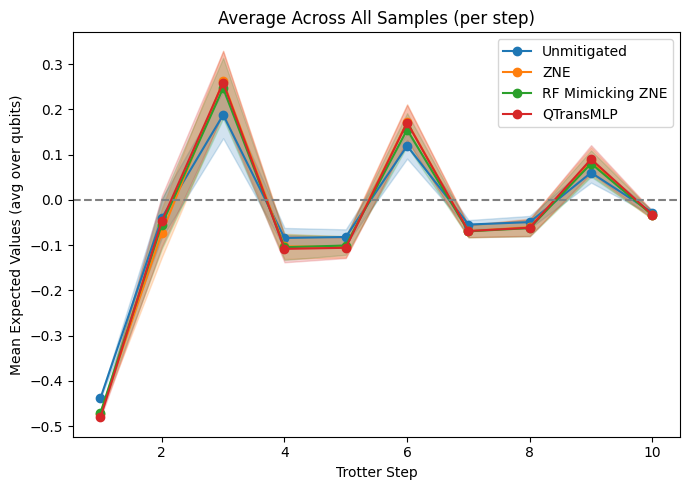

In [33]:
# --- Average curves across ALL samples (scalar per step) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# methods you may have; present ones will be plotted
CANDIDATES = ["noisy", "zne_mitigated", "rfr_list", "Transformer", "transformer"]

def _row_scalar(v):
    """
    v can be a list/np array of length M (per-qubit values) or a scalar.
    Return a scalar: mean over qubits for vectors; float for scalars.
    """
    if isinstance(v, (list, tuple, np.ndarray)):
        arr = np.asarray(v, dtype=float)
        return float(arr.mean())
    # already scalar
    return float(v)

def summarize_global_scalar(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each step and each available method:
      1) Convert each row's vector to a scalar via mean over qubits.
      2) Compute mean and standard error across rows for that step.
    Returns wide dataframe indexed by step with mean_*/ste_* columns (scalars).
    """
    if "step" not in df.columns:
        raise KeyError("df must contain a 'step' column.")
    gb = df.groupby("step", sort=True)
    out = pd.DataFrame(index=sorted(df["step"].unique()))
    for col in CANDIDATES:
        if col not in df.columns: 
            continue
        # series of per-row scalars for each group
        per_step_scalars = gb[col].apply(lambda s: np.array([_row_scalar(x) for x in s]))
        # mean/ste over rows for each step
        out[f"mean_{col}"] = per_step_scalars.apply(lambda a: float(a.mean()) if a.size else np.nan)
        out[f"ste_{col}"]  = per_step_scalars.apply(lambda a: float(a.std(ddof=0)/np.sqrt(max(1,len(a)))) if a.size else np.nan)
    return out

# Build the summary on the SAME df_k you’re using
# (df_k already has 'step' and columns like 'noisy', 'rfr_list', 'Transformer')
summ = summarize_global_scalar(df)

# ---- Plot: one figure, one line per available method ----
plt.style.use({'figure.facecolor':'white'})
plt.figure(figsize=(7,5))

legend_map = {
    "mean_noisy": "Unmitigated",
    "mean_zne_mitigated": "ZNE",
    "mean_rfr_list": "RF Mimicking ZNE",
    "mean_Transformer": "Transformer",
    "mean_transformer": "Transformer",  # handle lowercase key
}

x = summ.index.values
i = 0
y_zne   = summ["mean_zne_mitigated"].values.astype(float)

for mean_col in [c for c in summ.columns if c.startswith("mean_")]:
    ste_col = mean_col.replace("mean_", "ste_")
    if ste_col not in summ.columns:
        continue
    y   = summ[mean_col].values.astype(float)
    ste = summ[ste_col].values.astype(float)
    label = legend_map.get(mean_col, mean_col.replace("mean_", ""))
    if label == "Transformer":
        label = "QTransMLP"

    # skip entirely-NaN series
    if np.isnan(y).all():
        continue

    plt.plot(x, y, marker='o', label=label, color=f"C{i}")
    plt.fill_between(x, y - ste, y + ste, alpha=0.2, color=f"C{i}")
    i += 1

plt.title("Average Across All Samples (per step)")
plt.xlabel("Trotter Step")
plt.ylabel("Mean Expected Values (avg over qubits)")
plt.axhline(0, color="gray", linestyle="dashed")
plt.legend()
plt.grid(False)
plt.tight_layout()
# plt.savefig("trotter-steps-comparison.png")
plt.show()


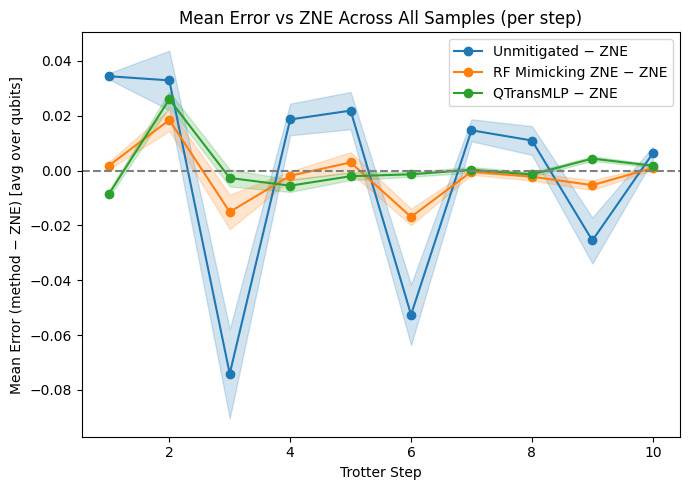

In [35]:
# --- Average ERROR vs ZNE across ALL samples (scalar per step) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# methods you may have; present ones will be plotted (except zne baseline)
CANDIDATES = ["noisy", "zne_mitigated", "rfr_list", "Transformer", "transformer"]

def _row_scalar(v):
    """
    v can be a list/np array of length M (per-qubit values) or a scalar.
    Return a scalar: mean over qubits for vectors; float for scalars.
    """
    if isinstance(v, (list, tuple, np.ndarray)):
        arr = np.asarray(v, dtype=float)
        return float(arr.mean())
    return float(v)

def summarize_error_vs_zne(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each step and each available method (excluding zne_mitigated baseline):
      1) Convert row's vectors to scalars (avg over qubits).
      2) Compute row-wise signed error: method_scalar - zne_scalar.
         (Use np.abs(...) below if you prefer absolute errors.)
      3) Aggregate across rows per step: mean error and STE.

    Returns wide dataframe indexed by step with meanerr_*/steerr_* columns.
    """
    if "step" not in df.columns:
        raise KeyError("df must contain a 'step' column.")
    if "zne_mitigated" not in df.columns:
        raise KeyError("df must contain 'zne_mitigated' as the ground-truth column.")

    # Precompute scalar versions per row for all available methods
    scalar_cols = {}
    for col in CANDIDATES:
        if col in df.columns:
            scalar_cols[col] = df[col].apply(_row_scalar)

    if "zne_mitigated" not in scalar_cols:
        raise KeyError("After scalar conversion, 'zne_mitigated' is missing.")

    zne_scalar = scalar_cols["zne_mitigated"]

    # Build a frame with step and per-method errors
    work = pd.DataFrame({"step": df["step"].values})
    for col, s in scalar_cols.items():
        if col == "zne_mitigated":
            continue
        # Signed error vs ZNE; switch to np.abs(s - zne_scalar) for absolute error
        work[col] = (s - zne_scalar).astype(float)

    gb = work.groupby("step", sort=True)
    out = pd.DataFrame(index=sorted(work["step"].unique()))

    for col in work.columns:
        if col == "step":
            continue
        per_step_arrays = gb[col].apply(lambda s: np.asarray(s.dropna().values, dtype=float))
        out[f"meanerr_{col}"] = per_step_arrays.apply(lambda a: float(a.mean()) if a.size else np.nan)
        out[f"steerr_{col}"]  = per_step_arrays.apply(
            lambda a: float(a.std(ddof=0)/np.sqrt(max(1, len(a)))) if a.size else np.nan
        )

    # Keep ZNE's own mean for plotting a reference zero line if desired (optional)
    out["mean_zne_mitigated"] = gb.apply(lambda g: float(zne_scalar.loc[g.index].mean()))
    return out

# Build the summary on the SAME df you’re using
summ = summarize_error_vs_zne(df)

# ---- Plot: one figure, one line per available method (errors vs ZNE) ----
plt.style.use({'figure.facecolor':'white'})
plt.figure(figsize=(7,5))

legend_map = {
    "meanerr_noisy": "Unmitigated − ZNE",
    "meanerr_rfr_list": "RF Mimicking ZNE − ZNE",
    "meanerr_Transformer": "QTransMLP − ZNE",
    "meanerr_transformer": "QTransMLP − ZNE",
}

x = summ.index.values
i = 0

# plot each method's error curve
for mean_col in [c for c in summ.columns if c.startswith("meanerr_")]:
    ste_col = mean_col.replace("meanerr_", "steerr_")
    if ste_col not in summ.columns:
        continue
    y   = summ[mean_col].values.astype(float)
    ste = summ[ste_col].values.astype(float)
    label = legend_map.get(mean_col, mean_col.replace("meanerr_", "") + " − ZNE")

    if np.isnan(y).all():
        continue

    plt.plot(x, y, marker='o', label=label, color=f"C{i}")
    plt.fill_between(x, y - ste, y + ste, alpha=0.2, color=f"C{i}")
    i += 1

plt.title("Mean Error vs ZNE Across All Samples (per step)")
plt.xlabel("Trotter Step")
plt.ylabel("Mean Error (method − ZNE) [avg over qubits]")
plt.axhline(0, color="gray", linestyle="dashed")
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.savefig("error-trotter-steps-error-vs-zne.png")
plt.show()


# Visualization

In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def get_graph_from_batch(batch, i: int):
    """
    Extract the i-th graph (0-based) from a PyG Batch or a list of Data.
    Returns a torch_geometric.data.Data.
    """
    if hasattr(batch, "to_data_list"):
        # Batch from DataLoader
        data_list = batch.to_data_list()
        return data_list[i]
    # Already a single Data
    return batch

def pairwise_jaccard(mask_bool: np.ndarray):
    """
    mask_bool: [N, M] boolean (True if node in qubit-m lightcone)
    Returns:
      J: [M, M] Jaccard overlaps
      I: [M, M] intersection sizes
      U: [M, M] union sizes
    """
    M = mask_bool.shape[1]
    J = np.zeros((M, M), dtype=float)
    I = np.zeros((M, M), dtype=int)
    U = np.zeros((M, M), dtype=int)
    for a in range(M):
        A = mask_bool[:, a]
        for b in range(M):
            B = mask_bool[:, b]
            inter = int(np.logical_and(A, B).sum())
            union = int(np.logical_or(A, B).sum())
            I[a, b] = inter
            U[a, b] = union
            J[a, b] = (inter / union) if union > 0 else 0.0
    return J, I, U

def visualize_lightcones(
    data,
    title_prefix="Lightcone Masks",
    node_positions: dict = None,
    show_graph=True,
    show_masks=True,
    show_overlap=True
):
    """
    Visualize lightcone_masks in three ways:
      - Graph view: color nodes by qubit membership (overlap shown by darker/stacked alpha)
      - Mask heatmap: nodes x measured_qubits
      - Pairwise Jaccard heatmap + intersections
    If networkx is available, uses a layout on edge_index; else graph view is skipped.
    """
    # --- get masks and basic dims ---
    masks_t = data.lightcone_masks
    masks = masks_t.cpu().numpy().astype(bool)  # [N, M]
    N, M = masks.shape

    # --- compute overlaps ---
    J, I, U = pairwise_jaccard(masks)

    # --- Graph layout (optional via networkx) ---
    G = None
    pos = None
    nx_available = False
    if show_graph:
        try:
            import networkx as nx
            nx_available = True
            # Build graph
            ei = data.edge_index.cpu().numpy() if hasattr(data, "edge_index") else np.zeros((2,0), dtype=int)
            G = nx.DiGraph()
            G.add_nodes_from(range(N))
            G.add_edges_from(list(zip(ei[0].tolist(), ei[1].tolist())))
            if node_positions is not None:
                pos = node_positions
            else:
                # Spring layout is fine for mid-size graphs; for big graphs you may want a faster layout
                pos = nx.spring_layout(G, seed=42, k=None)  # k auto
        except Exception as e:
            print("[info] networkx graph view skipped:", e)
            nx_available = False

    # --- Colors for up to M=8 (extend if needed) ---
    base_colors = [
        (0.89, 0.10, 0.11),  # red
        (0.12, 0.47, 0.71),  # blue
        (0.20, 0.63, 0.17),  # green
        (0.58, 0.40, 0.74),  # purple
        (1.00, 0.50, 0.00),  # orange
        (0.65, 0.34, 0.16),  # brown
        (0.70, 0.70, 0.70),  # gray
        (0.10, 0.62, 0.47),  # teal
    ]
    # repeat if M > len(base_colors)
    colors = [base_colors[i % len(base_colors)] for i in range(M)]

    # --- Figure layout ---
    nrows = (1 if not show_graph else 1) + (1 if show_masks else 0) + (1 if show_overlap else 0)
    nrows = max(1, nrows)

    fig, axes = plt.subplots(nrows, 1, figsize=(10, 4*nrows))
    if nrows == 1:
        axes = [axes]
    ax_i = 0

    # 1) Graph view with overlayed qubit masks
    if show_graph and nx_available:
        ax = axes[ax_i]; ax_i += 1
        ax.set_title(f"{title_prefix}: Graph view (N={N}, M={M})")
        # draw edges light gray
        import networkx as nx
        nx.draw_networkx_edges(G, pos=pos, ax=ax, alpha=0.2)

        # Draw nodes multiple times, once per qubit, with alpha blending
        for m in tqdm(range(M)):
            nodes_m = np.where(masks[:, m])[0].tolist()
            nx.draw_networkx_nodes(
                G, pos=pos, nodelist=nodes_m, node_color=[colors[m]],
                node_size=60, alpha=0.35, ax=ax, label=f"q{m}"
            )

        # Nodes in no lightcone (if any): draw hollow
        in_any = np.any(masks, axis=1)
        nodes_none = np.where(~in_any)[0].tolist()
        if len(nodes_none) > 0:
            nx.draw_networkx_nodes(G, pos=pos, nodelist=nodes_none,
                                   node_size=50, node_color="none",
                                   edgecolors="lightgray", linewidths=0.5, ax=ax, label="none")
        ax.axis("off")
        ax.legend(loc="upper right", ncol=min(M, 4))

    # 2) Node×Qubit mask heatmap
    if show_masks:
        ax = axes[ax_i]; ax_i += 1
        ax.set_title(f"{title_prefix}: Node × Qubit mask")
        # sort nodes by how many masks cover them (to see structure)
        cover_counts = masks.sum(axis=1)
        order = np.argsort(-cover_counts)  # descending
        sorted_masks = masks[order, :]
        im = ax.imshow(sorted_masks.astype(float), aspect="auto", interpolation="nearest")
        ax.set_xlabel("Measured qubit")
        ax.set_ylabel("Nodes (sorted by coverage)")
        ax.set_xticks(range(M)); ax.set_xticklabels([f"q{m}" for m in range(M)])
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Mask (1=in lightcone, 0=out)")
        # quick stats
        ax.text(1.01, 0.0,
                f"nodes covered by ≥1: {int((cover_counts>0).sum())}/{N}\n"
                f"mean coverage per node: {cover_counts.mean():.2f}",
                transform=ax.transAxes, va="bottom")

    # 3) Pairwise Jaccard overlap heatmap
    if show_overlap:
        ax = axes[ax_i]; ax_i += 1
        ax.set_title(f"{title_prefix}: Pairwise overlap (Jaccard)")
        im2 = ax.imshow(J, vmin=0.0, vmax=1.0, cmap="viridis")
        ax.set_xticks(range(M)); ax.set_xticklabels([f"q{m}" for m in range(M)])
        ax.set_yticks(range(M)); ax.set_yticklabels([f"q{m}" for m in range(M)])
        for a in range(M):
            for b in range(M):
                ax.text(b, a, f"{J[a,b]:.2f}\n({I[a,b]}/{U[a,b]})",
                        ha="center", va="center", color="white", fontsize=8)
        cbar2 = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
        cbar2.set_label("Jaccard = |∩| / |∪|")

    plt.tight_layout()
    plt.show()


In [15]:
# Grab a batch from your loader (train or val), take the first graph
b = next(iter(train_loader))  # or val_loader
g0 = get_graph_from_batch(b, 0)

# Visualize
visualize_lightcones(
    g0,
    title_prefix="Lightcones (sample 0)",
    show_graph=True,    # requires networkx; if not installed, set False or install networkx
    show_masks=True,
    show_overlap=True
)


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f911efff0d0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f904417e040> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [18]:
import numpy as np
import torch

def _to_numpy_bool(x: torch.Tensor) -> np.ndarray:
    return x.detach().cpu().numpy().astype(bool)

def _edge_arrays(edge_index: torch.Tensor, num_nodes: int):
    ei = edge_index.detach().cpu().numpy()
    u, v = ei[0], ei[1]
    # treat as undirected for locality stats (deduplicate)
    undirected = set(tuple(sorted(pair)) for pair in zip(u, v))
    uu, vv = zip(*undirected) if undirected else ([], [])
    uu = np.array(uu, dtype=int)
    vv = np.array(vv, dtype=int)
    return uu, vv

def _pairwise_jaccard(mask_bool: np.ndarray):
    M = mask_bool.shape[1]
    J = np.zeros((M, M), dtype=float)
    for a in range(M):
        A = mask_bool[:, a]
        for b in range(M):
            B = mask_bool[:, b]
            inter = (A & B).sum()
            union = (A | B).sum()
            J[a, b] = (inter / union) if union > 0 else 0.0
    return J

def _distance_stats(data, masks_bool: np.ndarray):
    """
    Returns dict per qubit with mean distance to measured node (if available),
    normalized by graph 'diameter' from provided shortest_path (if present).
    If shortest_path or node_idx are missing, returns None entries.
    """
    out = []
    N, M = masks_bool.shape
    sp = getattr(data, "shortest_path", None)
    node_idx = getattr(data, "node_idx", None)
    if sp is None or node_idx is None:
        return [dict(mean_dist=None, norm_closeness=None) for _ in range(M)]

    sp = np.asarray(sp)
    # diameter = max finite entry
    finite = sp[np.isfinite(sp)] if np.issubdtype(sp.dtype, np.floating) else sp[sp >= 0]
    diam = float(finite.max()) if finite.size else None

    # normalize node_idx to 1D int array of length M
    idx = np.asarray(node_idx).reshape(-1).astype(int)
    if idx.size < M:
        # pad with -1 (invalid) to M
        pad = np.full((M - idx.size,), -1, dtype=int)
        idx = np.concatenate([idx, pad], axis=0)

    for m in range(M):
        src = idx[m]
        if src < 0 or src >= N:
            out.append(dict(mean_dist=None, norm_closeness=None))
            continue
        dists = sp[:, src]
        mask = masks_bool[:, m]
        if mask.sum() == 0:
            out.append(dict(mean_dist=0.0, norm_closeness=1.0 if diam and diam > 0 else None))
            continue
        # select finite / reachable nodes in the mask
        if np.issubdtype(dists.dtype, np.floating):
            sel = mask & np.isfinite(dists)
        else:
            sel = mask & (dists >= 0)
        if sel.sum() == 0:
            out.append(dict(mean_dist=None, norm_closeness=None))
            continue
        md = float(dists[sel].mean())
        if diam is not None and diam > 1e-9:
            # higher is better (closer/local)
            norm_closeness = float(1.0 - min(md / diam, 1.0))
        else:
            norm_closeness = None
        out.append(dict(mean_dist=md, norm_closeness=norm_closeness))
    return out

def lightcone_locality_report(data, print_per_qubit: bool = True):
    """
    Prints locality metrics for data.lightcone_masks (shape [N, M]):

    - coverage: |LC| / N (lower is more local)
    - internal_edge_frac: fraction of edges whose both endpoints lie in the lightcone (higher is more local)
    - boundary_ratio: crossing_edges / edges_incident_to_mask (lower is more local)
    - mean_pairwise_jaccard: average overlap among qubits (0..1)
    - distance stats (if `shortest_path` and `node_idx` present):
        * mean shortest-path distance within lightcone
        * normalized closeness = 1 - mean_dist/diameter (higher is more local)
    - composite locality_score per qubit:
        score = 0.4*(1-coverage) + 0.4*(internal_edge_frac) + 0.2*(norm_closeness or 0.0)

    Returns a dict of aggregated metrics; prints a per-qubit table if requested.
    """
    masks = _to_numpy_bool(data.lightcone_masks)  # [N, M]
    N, M = masks.shape
    uu, vv = _edge_arrays(data.edge_index, N)

    # Precompute edge endpoints in mask per qubit
    # For each m: internal if mask[u] & mask[v]; boundary if XOR
    per_qubit = []
    for m in range(M):
        in_m = masks[:, m]
        if uu.size == 0:
            internal_edges = 0
            boundary_edges = 0
            incident_edges = 0
        else:
            a = in_m[uu]
            b = in_m[vv]
            internal_edges = int(np.logical_and(a, b).sum())
            boundary_edges = int(np.logical_xor(a, b).sum())
            incident_edges = int((a | b).sum())
        covered = int(in_m.sum())
        coverage = covered / max(1, N)
        internal_edge_frac = (internal_edges / max(1, incident_edges)) if incident_edges > 0 else 0.0
        boundary_ratio = (boundary_edges / max(1, incident_edges)) if incident_edges > 0 else 0.0

        per_qubit.append(dict(
            covered=covered, coverage=coverage,
            internal_edges=internal_edges, boundary_edges=boundary_edges,
            incident_edges=incident_edges,
            internal_edge_frac=internal_edge_frac, boundary_ratio=boundary_ratio
        ))

    # Overlap/Jaccard summary
    J = _pairwise_jaccard(masks)
    if M > 1:
        tri = J[np.triu_indices(M, k=1)]
        mean_pairwise_jaccard = float(tri.mean()) if tri.size else 0.0
    else:
        mean_pairwise_jaccard = 0.0

    # Distance-based stats (optional)
    dist_stats = _distance_stats(data, masks)  # list of dicts
    for m in range(M):
        per_qubit[m].update(dist_stats[m])

    # Composite locality score
    for m in range(M):
        cov = per_qubit[m]["coverage"]
        intf = per_qubit[m]["internal_edge_frac"]
        ncl = per_qubit[m].get("norm_closeness", None)
        score = 0.4*(1.0 - cov) + 0.4*(intf) + 0.2*((ncl if ncl is not None else 0.0))
        per_qubit[m]["locality_score"] = float(score)

    # Aggregates
    agg = dict(
        N=int(N), M=int(M),
        mean_coverage=float(np.mean([pq["coverage"] for pq in per_qubit])),
        mean_internal_edge_frac=float(np.mean([pq["internal_edge_frac"] for pq in per_qubit])),
        mean_boundary_ratio=float(np.mean([pq["boundary_ratio"] for pq in per_qubit])),
        mean_pairwise_jaccard=mean_pairwise_jaccard,
        mean_norm_closeness=float(np.mean([pq["norm_closeness"] for pq in per_qubit if pq["norm_closeness"] is not None])) \
                             if any(pq.get("norm_closeness") is not None for pq in per_qubit) else None,
        mean_locality_score=float(np.mean([pq["locality_score"] for pq in per_qubit]))
    )

    # Print summary
    print("== Lightcone Locality Summary ==")
    print(f"N nodes: {agg['N']} | M qubits: {agg['M']}")
    print(f"Mean coverage:            {agg['mean_coverage']:.4f} (lower → more local)")
    print(f"Mean internal edge frac:  {agg['mean_internal_edge_frac']:.4f} (higher → more local)")
    print(f"Mean boundary ratio:      {agg['mean_boundary_ratio']:.4f} (lower → more local)")
    print(f"Mean pairwise Jaccard:    {agg['mean_pairwise_jaccard']:.4f} (overlap across qubits)")
    if agg["mean_norm_closeness"] is not None:
        print(f"Mean normalized closeness:{agg['mean_norm_closeness']:.4f} (higher → closer to measured node)")
    print(f"Composite locality score: {agg['mean_locality_score']:.4f} (higher → more local)\n")

    if print_per_qubit:
        print("per-qubit metrics:")
        header = ("q", "coverage", "internal_frac", "boundary", "mean_dist", "norm_close", "score")
        print("{:>2s}  {:>9s}  {:>13s}  {:>8s}  {:>9s}  {:>10s}  {:>7s}".format(*header))
        for m, pq in enumerate(per_qubit):
            md = pq.get("mean_dist")
            ncl = pq.get("norm_closeness")
            print("{:>2d}  {:9.4f}  {:13.4f}  {:8.4f}  {:9s}  {:>10s}  {:7.4f}".format(
                m,
                pq["coverage"],
                pq["internal_edge_frac"],
                pq["boundary_ratio"],
                ("{:.3f}".format(md) if md is not None else "None"),
                ("{:.3f}".format(ncl) if ncl is not None else "None"),
                pq["locality_score"]
            ))
    return agg, per_qubit

# ---- Example usage (no plots) ----
b = next(iter(train_loader))
g0 = b.to_data_list()[0]
_ = lightcone_locality_report(g0, print_per_qubit=True)


== Lightcone Locality Summary ==
N nodes: 19801 | M qubits: 5
Mean coverage:            0.0132 (lower → more local)
Mean internal edge frac:  0.0450 (higher → more local)
Mean boundary ratio:      0.9550 (lower → more local)
Mean pairwise Jaccard:    0.0815 (overlap across qubits)
Composite locality score: 0.4127 (higher → more local)

per-qubit metrics:
 q   coverage  internal_frac  boundary  mean_dist  norm_close    score
 0     0.0158         0.0526    0.9474  None             None   0.4147
 1     0.0137         0.0466    0.9534  None             None   0.4131
 2     0.0137         0.0466    0.9534  None             None   0.4131
 3     0.0137         0.0466    0.9534  None             None   0.4131
 4     0.0092         0.0326    0.9674  None             None   0.4094


In [19]:
import torch
import numpy as np

def aggregate_locality_metrics(loader, max_batches=None):
    """
    Compute mean locality metrics across all graphs in a DataLoader.

    Args:
        loader: PyG DataLoader (train_loader)
        max_batches: optional cap for speed (int)

    Returns:
        dict of mean metrics
    """
    agg_metrics = []
    batch_count = 0

    for batch in loader:
        graphs = batch.to_data_list()
        for g in graphs:
            agg, _ = lightcone_locality_report(g, print_per_qubit=False)
            agg_metrics.append(agg)
        batch_count += 1
        if max_batches is not None and batch_count >= max_batches:
            break

    # average across graphs
    keys = agg_metrics[0].keys()
    mean_metrics = {k: float(np.mean([m[k] for m in agg_metrics if m[k] is not None]))
                    for k in keys}
    return mean_metrics

# ---- Example usage ----
train_means = aggregate_locality_metrics(train_loader, max_batches=None)
print("== Mean metrics over training set ==")
for k, v in train_means.items():
    print(f"{k:>25s}: {v:.4f}")


== Lightcone Locality Summary ==
N nodes: 19801 | M qubits: 5
Mean coverage:            0.0132 (lower → more local)
Mean internal edge frac:  0.0450 (higher → more local)
Mean boundary ratio:      0.9550 (lower → more local)
Mean pairwise Jaccard:    0.0815 (overlap across qubits)
Composite locality score: 0.4127 (higher → more local)

== Lightcone Locality Summary ==
N nodes: 20711 | M qubits: 5
Mean coverage:            0.0137 (lower → more local)
Mean internal edge frac:  0.0473 (higher → more local)
Mean boundary ratio:      0.9527 (lower → more local)
Mean pairwise Jaccard:    0.0741 (overlap across qubits)
Composite locality score: 0.4134 (higher → more local)

== Lightcone Locality Summary ==
N nodes: 11921 | M qubits: 5
Mean coverage:            0.0133 (lower → more local)
Mean internal edge frac:  0.0451 (higher → more local)
Mean boundary ratio:      0.9549 (lower → more local)
Mean pairwise Jaccard:    0.0826 (overlap across qubits)
Composite locality score: 0.4127 (higher →

In [20]:
import numpy as np

def mean_ignore_none(values):
    vals = [v for v in values if v is not None]
    return float(np.mean(vals)) if vals else None

def aggregate_locality_metrics_per_qubit(loader, max_batches=None, verbose=False):
    """
    Aggregates per-qubit locality metrics over all graphs in a loader.
    Returns:
      - per_qubit_means: dict(q -> dict(metric -> mean))
      - M_max: maximum number of qubits encountered
      - n_graphs: total graphs processed
    """
    # metrics we collect from per_qubit dicts
    METRICS = ["coverage", "internal_edge_frac", "boundary_ratio",
               "mean_dist", "norm_closeness", "locality_score"]

    buckets = []  # buckets[q] -> dict(metric -> list of values)
    n_graphs = 0
    batch_count = 0

    for batch in loader:
        graphs = batch.to_data_list()
        for g in graphs:
            _, per_q = lightcone_locality_report(g, print_per_qubit=False)  # list of dicts len = M_g
            M_g = len(per_q)
            # grow buckets if needed
            while len(buckets) < M_g:
                buckets.append({m: [] for m in METRICS})
            # collect values
            for q in range(M_g):
                pq = per_q[q]
                for m in METRICS:
                    buckets[q][m].append(pq.get(m, None))
            n_graphs += 1
        batch_count += 1
        if max_batches is not None and batch_count >= max_batches:
            break

    # compute means per qubit
    per_qubit_means = {}
    for q, metric_lists in enumerate(buckets):
        per_qubit_means[q] = {m: mean_ignore_none(metric_lists[m]) for m in METRICS}

    if verbose:
        print(f"Processed {n_graphs} graphs across {batch_count} batches.")
        print("Per-qubit mean metrics:")
        header = ("q", "coverage", "internal_frac", "boundary", "mean_dist", "norm_close", "score")
        print("{:>2s}  {:>9s}  {:>13s}  {:>8s}  {:>9s}  {:>10s}  {:>7s}".format(*header))
        for q in sorted(per_qubit_means.keys()):
            row = per_qubit_means[q]
            def fmt(x, w):
                return ("{:."+str(w)+"f}").format(x) if isinstance(x, (int, float)) else "--"
            print("{:>2d}  {:>9}  {:>13}  {:>8}  {:>9}  {:>10}  {:>7}".format(
                q,
                fmt(per_qubit_means[q]["coverage"], 4),
                fmt(per_qubit_means[q]["internal_edge_frac"], 4),
                fmt(per_qubit_means[q]["boundary_ratio"], 4),
                fmt(per_qubit_means[q]["mean_dist"], 3),
                fmt(per_qubit_means[q]["norm_closeness"], 3),
                fmt(per_qubit_means[q]["locality_score"], 4),
            ))

    return per_qubit_means, len(buckets), n_graphs

# ---- Example usage ----
per_q_means, M_max, n_graphs = aggregate_locality_metrics_per_qubit(train_loader, max_batches=None, verbose=True)


== Lightcone Locality Summary ==
N nodes: 19801 | M qubits: 5
Mean coverage:            0.0132 (lower → more local)
Mean internal edge frac:  0.0450 (higher → more local)
Mean boundary ratio:      0.9550 (lower → more local)
Mean pairwise Jaccard:    0.0815 (overlap across qubits)
Composite locality score: 0.4127 (higher → more local)

== Lightcone Locality Summary ==
N nodes: 20711 | M qubits: 5
Mean coverage:            0.0137 (lower → more local)
Mean internal edge frac:  0.0473 (higher → more local)
Mean boundary ratio:      0.9527 (lower → more local)
Mean pairwise Jaccard:    0.0741 (overlap across qubits)
Composite locality score: 0.4134 (higher → more local)

== Lightcone Locality Summary ==
N nodes: 11921 | M qubits: 5
Mean coverage:            0.0133 (lower → more local)
Mean internal edge frac:  0.0451 (higher → more local)
Mean boundary ratio:      0.9549 (lower → more local)
Mean pairwise Jaccard:    0.0826 (overlap across qubits)
Composite locality score: 0.4127 (higher →